# Анализ данных платежей

Анализируем данные по платежам от донорров в адрес фондов, агрегируем данные отдельных платежей до уровня дней с учетом последующего прогнозирования следующего дня, генерируем и добавляем признаки, проверяем корреляции. 

На **текущем этапе** проводим предподготовку и EDA выгрузки из БД с реальными данными. 

<a id='К-содержанию'></a>
**Содержание проекта** \
[Загрузка и предобработка данных](#Загрузка-и-предобработка-данных)\
[Иследовательский анализ данных](#Исследовательский-анализ-данных)\
[Кодирование текстовых категорий](#Кодирование-текстовых-категорий)\
[Анализ целевого признака и общая корреляция исходных признаков](#Анализ-целевого-признака-и-общая-корреляция-исходных-признаков)\
[Агрегирование данных и генерация признаков](#Агрегирование-данных-и-генерация-признаков)\
[Корреляция данных и распределение целевого признака после агрегирования](#Корреляция-данных-и-распределение-целевого-признака-после-агрегирования)

In [1]:
%%capture
!pip install spacy
!python -m spacy download ru_core_news_sm

In [2]:
#импортируем библиотеки перед началом проекта одним блоком
import os
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import spacy
nlp = spacy.load("ru_core_news_sm")

# тесты для проверки корреляций
from phik.report import plot_correlation_matrix
from phik import phik_matrix

from sklearn.feature_extraction.text import TfidfVectorizer

from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# загружаем нужные модели и метрики
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import mutual_info_regression

from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import torch



In [3]:
# вынесем блок с настройками и функциями

# зададим стандарт датафрейма перед загрузкой
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.8f}'.format)
pd.set_option('future.no_silent_downcasting', True)

# устанавливаем фиксированное значение для всех случайных библиотек
RANDOM_STATE = 42

def seed_all(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
seed_all(RANDOM_STATE)

# вывод гистограммы и boxplot
def hist_box(data,column,hue=None):
    
    palette = sns.color_palette('hsv', n_colors=10)
    random_color = random.choice(palette)
    
    if hue == None:
        
        fig, axes = plt.subplots(1, 2, figsize=(7, 2)) 
        ax = axes[0]
        sns.histplot(data=data, x=column, bins=10, 
                     color=random_color,
                     alpha=0.6,
                     legend='auto', ax=ax)
    else:
        fig, axes = plt.subplots(1, 2, figsize=(7, 2)) 
        ax = axes[0]
        sns.histplot(data=data, x=column, bins=10, 
                     color=random_color,
                     alpha=0.6,
                     hue=hue, 
                     multiple='stack',
                     legend='auto', ax=ax)
        

    ax = axes[1]
    sns.boxplot(x=data[column], color=random_color, ax=ax)
    ax.set_ylabel('')

    plt.tight_layout()
    plt.show();

# функция предобработки текста
def preprocess_text(text):
    # удаляем знаки пунктуации
    text = re.sub(r'[^\w\s]', ' ', text)
    # приводим к нижнему регистру
    text = text.lower()
    # делаем лемматизацию с использованием spaCy
    doc = nlp(text)
    text = " ".join([token.lemma_ for token in doc])
    return text

# задаем функцию для получения усредненного эмбеддинга текста
def get_embedding(text,tokenizer,model):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

<a id='Загрузка-и-предобработка-данных'></a> 
## Загрузка и предобработка данных
[К содержанию](#К-содержанию)

In [4]:
# импортируем тренировочные данные
pth1 = 'data_1.csv'
pth2 = 'users_actual.csv'

if os.path.exists(pth1) and os.path.exists(pth2):
    data_full = pd.read_csv(pth1)
    users_actual = pd.read_csv(pth2)
else:
    print('Something is wrong')

data_full.info()
display(data_full.head())
display(users_actual.head())

/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_58755/2402617703.py:6: DtypeWarning: Columns (23,25,29,32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  data_full = pd.read_csv(pth1)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567663 entries, 0 to 567662
Data columns (total 42 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     567663 non-null  int64  
 1   account_id                             567663 non-null  int64  
 2   contractor_id                          567663 non-null  int64  
 3   expenditure                            567663 non-null  object 
 4   status                                 567663 non-null  object 
 5   date                                   567663 non-null  object 
 6   payments_amount                        567663 non-null  float64
 7   purpose                                566089 non-null  object 
 8   deleted_at                             0 non-null       float64
 9   article_id                             567663 non-null  int64  
 10  project_id                             567663 non-null  

,id,account_id,contractor_id,expenditure,status,date,payments_amount,purpose,deleted_at,article_id,project_id,counterpartie_id,donor_id,hidden,robot_id,donor_cat_id,user_directory_id,accounts__id,accounts__number,accounts__name,accounts__user_id,articles__id,articles__user_id,articles__type,articles__parent_id,articles__name,projects__id,projects__user_id,projects__parent_id,projects__name,counterparties__id,counterparties__user_id,counterparties__type,counterparties__parent_id,counterparties__name,robots__id,robots__user_id,robots__account_id,robots__article_id,robots__project_id,article_alternative_names__article_id,article_alternative_names__user_id
0,6000,28,1210,incoming,paid,2022-05-18,17500.00000000,"Оплата по договору об оказании услуг № 4 от 16.05.2022 за услуги по консультированию, НДС не облагается.",NaN,378,75,137,0,0,-1,135,0,28.00000000,40802810901500300415,ТОЧКА,41.00000000,378.00000000,41.00000000,incoming,376.00000000,Услуги,75.00000000,41.00000000,17.00000000,Услуги,135.00000000,41.00000000,entity,133.00000000,Компании,NaN,NaN,NaN,NaN,NaN,378.00000000,41.00000000
1,6002,28,1210,incoming,paid,2022-06-01,17500.00000000,"Оплата по договору об оказании услуг № 4 от 16.05.2022 за услуги по консультированию, НДС не облагается.",NaN,378,75,137,0,0,-1,135,0,28.00000000,40802810901500300415,ТОЧКА,41.00000000,378.00000000,41.00000000,incoming,376.00000000,Услуги,75.00000000,41.00000000,17.00000000,Услуги,135.00000000,41.00000000,entity,133.00000000,Компании,NaN,NaN,NaN,NaN,NaN,378.00000000,41.00000000
2,6015,28,1207,outgoing,paid,2022-06-26,25638.34000000,"Покупка товара(Терминал:US PETUSHKOVA VISA,3-2 VASILIYA PETUSHKOVA STR,MOSCOW,RU,дата операции:23/06/2022 18:21(МСК),на сумму:25638.34 RUB,карта 5140********0383)",NaN,9721,75,0,0,0,-1,135,0,28.00000000,40802810901500300415,ТОЧКА,41.00000000,9721.00000000,41.00000000,outgoing,385.00000000,ФОТ. Управление,75.00000000,41.00000000,17.00000000,Услуги,135.00000000,41.00000000,entity,133.00000000,Компании,NaN,NaN,NaN,NaN,NaN,9721.00000000,41.00000000
3,6015,28,1207,outgoing,paid,2022-06-26,25638.34000000,"Покупка товара(Терминал:US PETUSHKOVA VISA,3-2 VASILIYA PETUSHKOVA STR,MOSCOW,RU,дата операции:23/06/2022 18:21(МСК),на сумму:25638.34 RUB,карта 5140********0383)",NaN,9721,75,0,0,0,-1,135,0,28.00000000,40802810901500300415,ТОЧКА,41.00000000,9721.00000000,41.00000000,outgoing,385.00000000,ФОТ. Управление,75.00000000,41.00000000,17.00000000,Услуги,135.00000000,41.00000000,entity,133.00000000,Компании,NaN,NaN,NaN,NaN,NaN,9721.00000000,41.00000000
4,6016,28,1207,outgoing,paid,2022-06-26,119.00000000,"Покупка товара(Терминал:KFC EVROPEISKY.,2 KIEVSKOGO VOKZALA SQ,MOSCOW,RU,дата операции:23/06/2022 09:30(МСК),на сумму:119 RUB,карта 5140********0383)",NaN,9721,75,0,0,0,-1,135,0,28.00000000,40802810901500300415,ТОЧКА,41.00000000,9721.00000000,41.00000000,outgoing,385.00000000,ФОТ. Управление,75.00000000,41.00000000,17.00000000,Услуги,135.00000000,41.00000000,entity,133.00000000,Компании,NaN,NaN,NaN,NaN,NaN,9721.00000000,41.00000000


,id
0,47
1,65
2,98
3,101
4,114


In [5]:
# посмотрим на варианты заполнения некоторых столбцов
display(data_full['expenditure'].unique(),
        data_full['status'].unique(),
        data_full['user_directory_id'].unique(),
        data_full['deleted_at'].unique()
)


array(['incoming', 'outgoing'], dtype=object)

array(['paid', 'agreed'], dtype=object)

array([0])

array([nan])

In [6]:
# посмотрим сколько входящих платежей с нетиповыми статусами draft и agreed
display(data_full[(data_full['expenditure'] == 'incoming')&(data_full['status'] == 'agreed')]['id'].count())

# и исходящих
data_full[(data_full['expenditure'] == 'outgoing')&(data_full['status'] == 'agreed')]['id'].count()


1

367

In [7]:
# соответственно можем отобрать входящие платежи - т.к. будем прогнозировать поступления и исключим драфты, обещанные платежи 
# и исключим столбцы user_directory_id, deleted_at - он нулевой, и отфильтрованные столбцы - они с однимм значением

data = data_full[(data_full['expenditure'] == 'incoming')&(data_full['status'] == 'paid')]
data = data.drop(['user_directory_id','expenditure','status','deleted_at'],axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 411434 entries, 0 to 567204
Data columns (total 38 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     411434 non-null  int64  
 1   account_id                             411434 non-null  int64  
 2   contractor_id                          411434 non-null  int64  
 3   date                                   411434 non-null  object 
 4   payments_amount                        411434 non-null  float64
 5   purpose                                410518 non-null  object 
 6   article_id                             411434 non-null  int64  
 7   project_id                             411434 non-null  int64  
 8   counterpartie_id                       411434 non-null  int64  
 9   donor_id                               411434 non-null  int64  
 10  hidden                                 411434 non-null  int64

In [8]:
data.head()

,id,account_id,contractor_id,date,payments_amount,purpose,article_id,project_id,counterpartie_id,donor_id,hidden,robot_id,donor_cat_id,accounts__id,accounts__number,accounts__name,accounts__user_id,articles__id,articles__user_id,articles__type,articles__parent_id,articles__name,projects__id,projects__user_id,projects__parent_id,projects__name,counterparties__id,counterparties__user_id,counterparties__type,counterparties__parent_id,counterparties__name,robots__id,robots__user_id,robots__account_id,robots__article_id,robots__project_id,article_alternative_names__article_id,article_alternative_names__user_id
0,6000,28,1210,2022-05-18,17500.00000000,"Оплата по договору об оказании услуг № 4 от 16.05.2022 за услуги по консультированию, НДС не облагается.",378,75,137,0,0,-1,135,28.00000000,40802810901500300415,ТОЧКА,41.00000000,378.00000000,41.00000000,incoming,376.00000000,Услуги,75.00000000,41.00000000,17.00000000,Услуги,135.00000000,41.00000000,entity,133.00000000,Компании,NaN,NaN,NaN,NaN,NaN,378.00000000,41.00000000
1,6002,28,1210,2022-06-01,17500.00000000,"Оплата по договору об оказании услуг № 4 от 16.05.2022 за услуги по консультированию, НДС не облагается.",378,75,137,0,0,-1,135,28.00000000,40802810901500300415,ТОЧКА,41.00000000,378.00000000,41.00000000,incoming,376.00000000,Услуги,75.00000000,41.00000000,17.00000000,Услуги,135.00000000,41.00000000,entity,133.00000000,Компании,NaN,NaN,NaN,NaN,NaN,378.00000000,41.00000000
8,6026,28,56625,2022-08-17,28900.00000000,ошибочно зачисленные НДС не облагается,383,2641,141,333,0,-1,0,28.00000000,40802810901500300415,ТОЧКА,41.00000000,383.00000000,41.00000000,incoming,381.00000000,Возврат,2641.00000000,41.00000000,0.00000000,Ы_Возвраты,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,6028,28,1207,2022-08-17,200000.00000000,Перевод по номеру телефона +79166636302 Отправитель АННА АЛЕКСАНДРОВНА М. через СБП.,1068,74,0,333,0,-1,0,28.00000000,40802810901500300415,ТОЧКА,41.00000000,1068.00000000,41.00000000,incoming,987.00000000,Транш инвестиций,74.00000000,41.00000000,0.00000000,Лемонпай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1068.00000000,41.00000000
13,6079,28,1207,2022-10-21,300000.00000000,Перевод по номеру телефона +79166636302 Отправитель АННА АЛЕКСАНДРОВНА М. через СБП.,1068,74,139,333,0,-1,0,28.00000000,40802810901500300415,ТОЧКА,41.00000000,1068.00000000,41.00000000,incoming,987.00000000,Транш инвестиций,74.00000000,41.00000000,0.00000000,Лемонпай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1068.00000000,41.00000000


In [9]:
cols = ['accounts__user_id', 'articles__user_id', 'projects__user_id','counterparties__user_id', 'robots__user_id','article_alternative_names__user_id']

# проверяем, что в каждой строке либо все значения одинаковые, либо содержат только NaN
mask = data[cols].apply(lambda x: x.nunique(dropna=True) <= 1, axis=1)

# Проверяем, что условие выполняется во всех строках
all_rows_valid = mask.all()

display(all_rows_valid)  # будет True, если во всех строках соблюдено условие, иначе False

display(data[~mask]) # выводим строки, где есть несовпадения


True

,id,account_id,contractor_id,date,payments_amount,purpose,article_id,project_id,counterpartie_id,donor_id,hidden,robot_id,donor_cat_id,accounts__id,accounts__number,accounts__name,accounts__user_id,articles__id,articles__user_id,articles__type,articles__parent_id,articles__name,projects__id,projects__user_id,projects__parent_id,projects__name,counterparties__id,counterparties__user_id,counterparties__type,counterparties__parent_id,counterparties__name,robots__id,robots__user_id,robots__account_id,robots__article_id,robots__project_id,article_alternative_names__article_id,article_alternative_names__user_id


In [10]:
display(data['accounts__user_id'].isna().sum())

# заполняем accounts__user_id значениями из других столбцов
data['accounts__user_id'] = (
    data['accounts__user_id']
    .fillna(data['articles__user_id'])
    .fillna(data['projects__user_id'])
    .fillna(data['counterparties__user_id'])
    .fillna(data['robots__user_id'])
    .fillna(data['article_alternative_names__user_id'])
)

display(data['accounts__user_id'].isna().sum())

21076

18840

Получается огромная разреженная таблица, которая сильно "утяжелит" датасет, при этом значения категорий вполне могут быть переданы столбцами id - в таком случае нет смысла кодировать названия статей, проектов, контрагентов. Имеет смысл закодировать только назначение платежа с помщью эмбеддингов в единое скалярное значение или выделить главные компоненты из эмбеддинга.

In [11]:
# отфильтруем данные по актуальным пользователям и уберем технические поступления - возврат депозитов, переводы собственных средств
data_actual_id_wodepo = data[~data['purpose'].str.contains('вклад', na=False) & 
                             ~data['purpose'].str.contains('депози', na=False) &
                             ~data['purpose'].str.contains('собствен', na=False)&
                             ~data['purpose'].str.contains('процент', na=False)&
                             data['accounts__user_id'].isin(users_actual['id'])]

data_actual_id_wodepo['id'].count()

249513

In [12]:
# столбцы с дублирующими id, которые использовались при объединении данных при выгрузке из БД, также пустые столбцы и техстолбцы с одним значением
data = data_actual_id_wodepo.drop(['hidden','robot_id','accounts__id','accounts__number','accounts__name','articles__id',
                                   'articles__user_id','articles__type','projects__id','projects__user_id','counterparties__id',
                                   'counterparties__user_id','robots__user_id','robots__account_id','robots__article_id',
                                   'robots__project_id','article_alternative_names__article_id','article_alternative_names__user_id'], axis=1)


In [13]:
# поправим типы данных и заполним пропуски метками missing (для текстовых значений категорий) и 0 для пропущенных ID
data[['articles__parent_id','projects__parent_id','counterparties__parent_id','robots__id']] = data[['articles__parent_id','projects__parent_id','counterparties__parent_id','robots__id']].fillna(0).astype('int64')

data[['purpose','articles__name','projects__name','counterparties__type','counterparties__name']] = data[['purpose','articles__name','projects__name','counterparties__type','counterparties__name']].fillna('missing')

# конвертируем дату в datetime
data['date'] = pd.to_datetime(data['date'])

# переименуем и поправим тип столбца с фондами
data = data.rename(columns={'accounts__user_id': 'user_id'})
data['user_id'] = data['user_id'].fillna(0).astype('int64')

# поменяем индекс на значения date и отсортируем строки по индексу
data = data.sort_values(by=["date", "user_id"]).reset_index(drop=True)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249513 entries, 0 to 249512
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id                         249513 non-null  int64         
 1   account_id                 249513 non-null  int64         
 2   contractor_id              249513 non-null  int64         
 3   date                       249513 non-null  datetime64[ns]
 4   payments_amount            249513 non-null  float64       
 5   purpose                    249513 non-null  object        
 6   article_id                 249513 non-null  int64         
 7   project_id                 249513 non-null  int64         
 8   counterpartie_id           249513 non-null  int64         
 9   donor_id                   249513 non-null  int64         
 10  donor_cat_id               249513 non-null  int64         
 11  user_id                    249513 non-null  int64   

<a id='Кодирование-текстовых-категорий'></a> 
## Кодирование текстовых категорий
[К содержанию](#К-содержанию)

In [15]:
# преобразуем текстовые описания для примера в articles__name в числовые векторы и далее с помощью корреляционной таблицы проверим насколько актуально оставлять текстовые признаки
vectorizer = TfidfVectorizer(
    min_df=0.01,  # игнорируем слова, встречающиеся менее чем в 1% документов
    max_df=0.95,  # игнорируем слова, встречающиеся более чем в 95% документов
    ngram_range=(1, 2)  # учитываем биграммы (пары слов)
)

tfidf_matrix = vectorizer.fit_transform(data['articles__name'].fillna(''))
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.head(3)

,cloudpayments,missing,predannoeserdce,qr,альфа,альфа банк,альфы,банк,банк банк,банк благотворительность,банк физ,банка,благо,благотворительность,благотворительность напрямую,во,во благо,добросвет,из,из приложения,кешбэк,кешбэк во,лиц,лица,лица напрямую,на,на альфы,на через,напрямую,напрямую из,напрямую на,от,от физ,пожертвование,пожертвование на,пожертвование через,пожертвования,приложение,приложения,приложения банка,сайт,сбербанк,сбп,сбп терминал,тбанк,тбанк благотворительность,тбанк кешбэк,тбанк сбп,терминал,терминал predannoeserdce,тинькоф,тинькоф приложение,тинькофф,тинькофф благотворительность,тинькофф приложение,физ,физ лица,фл,через,через банк,через добросвет,через сайт,через тинькоф,через тинькофф,юр,юр лица
0,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
1,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000


In [16]:
data = data.drop(['articles__name','projects__name','counterparties__type','counterparties__name'], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249513 entries, 0 to 249512
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id                         249513 non-null  int64         
 1   account_id                 249513 non-null  int64         
 2   contractor_id              249513 non-null  int64         
 3   date                       249513 non-null  datetime64[ns]
 4   payments_amount            249513 non-null  float64       
 5   purpose                    249513 non-null  object        
 6   article_id                 249513 non-null  int64         
 7   project_id                 249513 non-null  int64         
 8   counterpartie_id           249513 non-null  int64         
 9   donor_id                   249513 non-null  int64         
 10  donor_cat_id               249513 non-null  int64         
 11  user_id                    249513 non-null  int64   

In [17]:
# посмотрим на текстовое поле с назначением платежа 
display(data['purpose'].nunique())
display(data['purpose'].value_counts().head(20))

64074

purpose
Благотворительное пожертвование на уставную деятельность. НДС не облагается                                                                                                                             81724
missing                                                                                                                                                                                                   446
Добровольное пожертвование 100.00;                                                                                                                                                                        426
Перевод между счетами. Без НДС                                                                                                                                                                            400
Зачисление средств по операциям эквайринга. Мерчант №341000091806. Комиссия 2.00. НДС не облагается.                                                                    

In [18]:
# подберем модель для вычисления эмбеддинга текстового поля, потестируем несколько популярных моделей для русского языка на нескольких наборах данных

# количество записей по каждому фонду
data['user_id'].value_counts().head(10)

user_id
804    96616
812    36681
114    33490
195    13466
722     7994
185     7159
890     6098
237     5792
888     4621
827     4365
Name: count, dtype: int64

In [19]:
# сколько всего уникальных значений в столбце назначения платежа 
data_actual_id_wodepo['purpose'].nunique()

# и разбивку уникальных значений назначения плтаежа по фондам
data_actual_id_wodepo.groupby('accounts__user_id')['purpose'].nunique().sort_values(ascending=False)

accounts__user_id
804.00000000    12105
114.00000000     8684
195.00000000     5824
722.00000000     4898
827.00000000     4075
237.00000000     3637
279.00000000     2851
172.00000000     2540
185.00000000     2262
838.00000000     1924
749.00000000     1862
812.00000000     1660
822.00000000     1543
890.00000000     1224
123.00000000     1025
47.00000000       965
724.00000000      872
782.00000000      817
709.00000000      740
792.00000000      645
816.00000000      587
714.00000000      435
197.00000000      403
712.00000000      378
168.00000000      346
888.00000000      331
777.00000000      317
877.00000000      287
876.00000000      281
65.00000000       264
272.00000000      236
795.00000000      165
256.00000000      144
98.00000000       136
732.00000000      103
176.00000000       89
886.00000000       39
284.00000000        8
874.00000000        4
157.00000000        0
Name: purpose, dtype: int64

С учетом полученного среза возьмем фонды  с user_id 114, 195, 185, 237, 827 для тестирования методов кодирования поля с назначением платежа, чтобы суммарно получить достаточно болшое количество вариантов назначений платежа.

In [20]:
# зададим кэш-файл с результатами теста, чтобы повторно не прогонять тест
lang_model_test = "lang_model_test.parquet"

# проверяем существование файла с результатами
if os.path.exists(lang_model_test):
    print(f"Найден файл {lang_model_test}, загружаем данные")
    data_processed = pd.read_parquet(lang_model_test)
    # Выводим результаты из файла с результатами
    display(data_processed)
else:
    print(f"Кэш-файл не найден, запускаем полную обработку")
    
    # задаем списки тестовых фондов и языковых моделей для кодирования
    lan_model_list = ['DeepPavlov/rubert-base-cased','sentence-transformers/LaBSE']
    fund_list = [114,195,185,237,827]
    
    # список для хранения результатов
    results = []

    for lan_model in lan_model_list:
        
        # загрузка модели и токенизатора
        tokenizer = AutoTokenizer.from_pretrained(lan_model)
        model = AutoModel.from_pretrained(lan_model)

        print('\nLanguage model:', lan_model)

        for fund in fund_list:

            data_= data[data['user_id'] == fund].copy()
            print('\nФонд:', fund)
            
            # применяем предобработку к колонке с назначением платежа
            tqdm.pandas(desc="Предобработка текстов")
            data_["clean_purpose"] = data_["purpose"].progress_apply(preprocess_text)
            
            # применяем функцию для кодирования поля назначения платежа
            tqdm.pandas(desc="Генерация эмбеддингов")
            data_["purpose_emb"] = data_["clean_purpose"].progress_apply(lambda x: get_embedding(x, tokenizer, model))
            
            # 1. еще раз усредняем эмбеддинг до единственного значения
            data_["purpose_mean"] = data_["purpose_emb"].apply(np.mean)

            # 2. выбираем из эмбеддинга 5 главных компонент с помощью PCA
            purpose_vectors = np.vstack(data_["purpose_emb"])
            pca_catboost = PCA(n_components=5)
            purpose_pca_catboost = pca_catboost.fit_transform(purpose_vectors)

            n_components = purpose_pca_catboost.shape[1]
            pca_column_names = [f"purpose_pca_{i+1}" for i in range(n_components)]  # генерируем названия столбцов для главных компонент
            data_[pca_column_names] = purpose_pca_catboost

            # делим данные
            X = data_.drop(columns=["payments_amount", "purpose", "purpose_emb"])  # убираем ненужные столбцы
            y = data_["payments_amount"]

            # задаем два способа кодирования эмбеддингов из заданных выше
            methods = {
                "mean_embedding": ["purpose_mean"],  # усреднение эмбеддинга
                "pca_embedding": pca_column_names  # главные компоненты
            }

            # тестируем на каждой версии данных
            for method_name, features in methods.items():
                
                # выбираем закодированные значения столбца "назначение платежа"
                X_encoded = X[features].copy()

                # кросс-валидация с RandomForest
                rf_scores = cross_val_score(RandomForestRegressor(), X_encoded, y, cv=5, scoring="neg_mean_squared_error")
                rf_rmse = np.round(np.sqrt(abs(rf_scores.mean())),2)
                print(f"{method_name} - RandomForest RMSE: {rf_rmse:.2f}")
                
                # сохраняем результат в список
                results.append({
                    "language_model": lan_model,
                    "fund": fund,
                    "method": method_name,
                    "model": "RandomForest",
                    "rmse": rf_rmse
                })
                
                # кросс-валидация с нейросетью
                nn_scores = cross_val_score(MLPRegressor(solver="adam", learning_rate_init=0.01, max_iter=1000, random_state=RANDOM_STATE), X_encoded, y, cv=5, scoring="neg_mean_squared_error")
                nn_rmse = np.round(np.sqrt(abs(nn_scores.mean())), 2)
                print(f"{method_name} - NN RMSE: {nn_rmse:.2f}")
                
                # сохраняем результат в список
                results.append({
                    "language_model": lan_model,
                    "fund": fund,
                    "method": method_name,
                    "model": "Neural Network",
                    "rmse": nn_rmse
                })
    
    # Создаем DataFrame с результатами
    data_processed = pd.DataFrame(results).sort_values(by="rmse", ascending=True)
    
    # Сохраняем результаты в parquet файл
    data_processed.to_parquet(lang_model_test)
    

Найден файл lang_model_test.parquet, загружаем данные


,language_model,fund,method,model,rmse
23,sentence-transformers/LaBSE,114,pca_embedding,Neural Network,15562.78000000
3,DeepPavlov/rubert-base-cased,114,pca_embedding,Neural Network,16299.43000000
21,sentence-transformers/LaBSE,114,mean_embedding,Neural Network,16504.16000000
1,DeepPavlov/rubert-base-cased,114,mean_embedding,Neural Network,16505.02000000
22,sentence-transformers/LaBSE,114,pca_embedding,RandomForest,16640.64000000
2,DeepPavlov/rubert-base-cased,114,pca_embedding,RandomForest,17345.79000000
0,DeepPavlov/rubert-base-cased,114,mean_embedding,RandomForest,18653.02000000
20,sentence-transformers/LaBSE,114,mean_embedding,RandomForest,18836.44000000
10,DeepPavlov/rubert-base-cased,185,pca_embedding,RandomForest,45456.08000000
30,sentence-transformers/LaBSE,185,pca_embedding,RandomForest,48401.24000000


Анализируя RMSE для различных комбинаций моделей и методов кодирования эмбеддингов, можно сделать следующие выводы:

1.	PCA-embedding чаще даёт более низкие RMSE, чем mean-embedding, особенно при использовании RandomForest.
2.	DeepPavlov/rubert-base-cased стабильно лучше sentence-transformers/LaBSE на всех фондах в среднем.

Дополнительно можно выделить, что 
1.	PCA даёт значимое снижение RMSE для RandomForest (~10.7%) в DeepPavlov/rubert-base-cased.
2.	Для NN разница не столь значима (~3%).
3.	В sentence-transformers/LaBSE PCA почти не даёт прироста (1.8-2.8%).
4.	Дополнительные 5 столбцов требуют агрегирования (например, усреднения).

**Вывод**:  
Т.к. далее при обучении планируется использовать catboost и нейронную сеть в том числе на текстовом признаке, то имеет смысл использовать языковую модель DeepPavlov/rubert-base-cased и применять PCA для упрощения эмбеддинга.   

Но применение PCA усложнит датасет за счет добавления 5 новых столбцов, которые в свою очередь потребуют при агрегации дополнительных ресурсов - имеет смысл при обучении моделей обратить внимание на вклад этих признаков (текстовый признак в целом второстепенен) и возможно вернуться к простому среднению закодированного эмбеддинга вместо 5 главных компонент.

In [21]:
# закодируем текстовое поле
if os.path.exists("data_with_purpose_mean.parquet"):
    data = pd.read_parquet("data_with_purpose_mean.parquet")
else:
    tokenizer = AutoTokenizer.from_pretrained('DeepPavlov/rubert-base-cased')
    model = AutoModel.from_pretrained('DeepPavlov/rubert-base-cased')

    # предобработка текста
    tqdm.pandas(desc="Предобработка текстов")
    data["clean_purpose"] = data["purpose"].progress_apply(preprocess_text)

    # генерация эмбеддингов
    tqdm.pandas(desc="Генерация эмбеддингов")
    data["purpose_emb"] = data["clean_purpose"].progress_apply(lambda x: get_embedding(x, tokenizer, model))

    # 1. усредняем эмбеддинг в одно число
    data["purpose_mean"] = data["purpose_emb"].apply(lambda x: float(np.mean(x)))

    # 2. PCA на 5 главных компонентах
    purpose_vectors = np.vstack(data["purpose_emb"])
    pca = PCA(n_components=5)
    purpose_pca_features = pca.fit_transform(purpose_vectors)

    pca_column_names = [f"purpose_pca_{i+1}" for i in range(5)]
    data[pca_column_names] = purpose_pca_features

    # удаляем ненужные столбцы
    data.drop(columns=["purpose", "clean_purpose", "purpose_emb"], inplace=True)

    # сохраняем результат
    data.to_parquet("data_with_purpose_mean.parquet", index=False)

In [22]:
data = data.sort_values(by=["date", "user_id"]).reset_index(drop=True)
data.head()

,id,account_id,contractor_id,date,payments_amount,article_id,project_id,counterpartie_id,donor_id,donor_cat_id,user_id,articles__parent_id,projects__parent_id,counterparties__parent_id,robots__id,purpose_mean,purpose_pca_1,purpose_pca_2,purpose_pca_3,purpose_pca_4,purpose_pca_5
0,492857,2051,83878,2020-11-20,1000.00000000,0,0,0,0,0,838,0,0,0,0,0.00094185,-5.38070059,-1.04426587,-0.23564315,-0.04214036,0.05035734
1,494852,2052,40261,2020-12-06,800.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671
2,494853,2052,40261,2020-12-06,100.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671
3,494854,2052,40261,2020-12-06,300.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671
4,494855,2052,40261,2020-12-06,300.00000000,0,0,0,0,0,838,0,0,0,0,-0.00270794,2.40096283,-2.15824342,-2.43168974,0.44952154,0.45905873


In [23]:
# проверим дубликаты
print('Количество дубликатов: ', data.duplicated().sum().sum())

# проверим пропуски
print('Количество пропусков: ', data.isna().sum().sum())

Количество дубликатов:  0
Количество пропусков:  0


<a id='Анализ-целевого-признака-и-общая-корреляция-исходных-признаков'></a> 
## Анализ целевого признака и общая корреляция исходных признаков
[К содержанию](#К-содержанию)

In [24]:
# посмотрим на активность пользователей в целом - посчитаем количество дней с платежами для каждого фонда
data_grouped = data.groupby(['user_id', 'date']).sum().reset_index()

user_activity = data_grouped.groupby('user_id')['date'].nunique().reset_index()
user_activity.columns = ['user_id', 'active_days']

user_activity.sort_values(by='active_days', ascending=False)

,user_id,active_days
33,838,1045
10,195,745
9,185,697
7,172,693
23,749,507
4,123,489
3,114,394
21,724,393
12,237,393
39,890,388


ID: 804
Количество записей: 96616


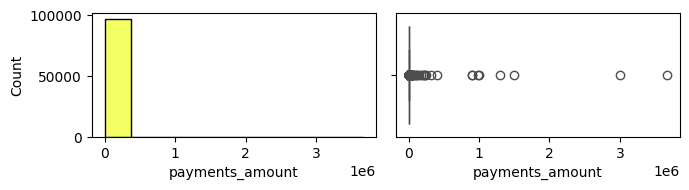

ID: 812
Количество записей: 36681


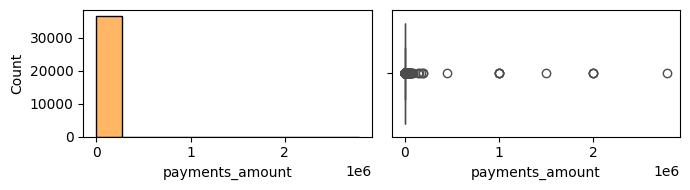

ID: 114
Количество записей: 33490


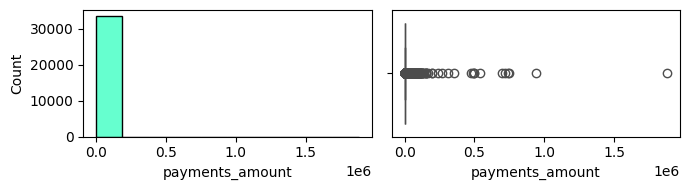

ID: 195
Количество записей: 13466


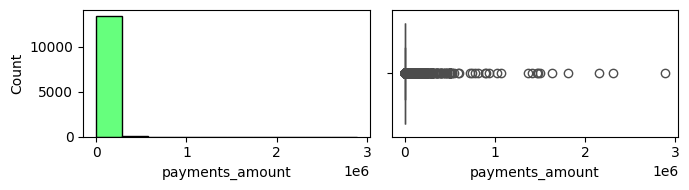

ID: 722
Количество записей: 7994


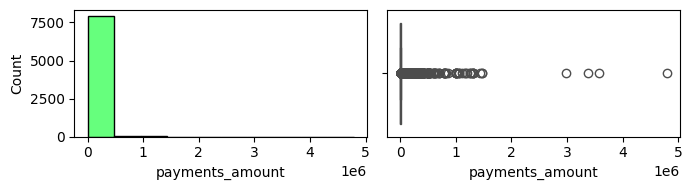

ID: 185
Количество записей: 7159


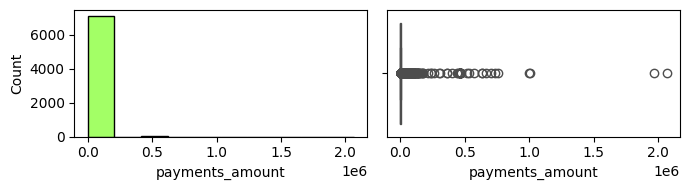

ID: 890
Количество записей: 6098


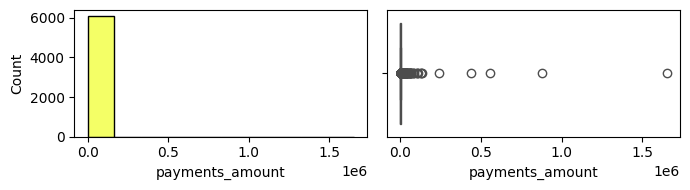

ID: 237
Количество записей: 5792


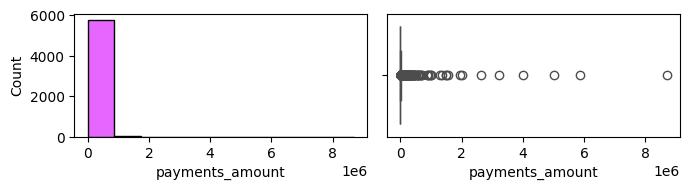

ID: 888
Количество записей: 4621


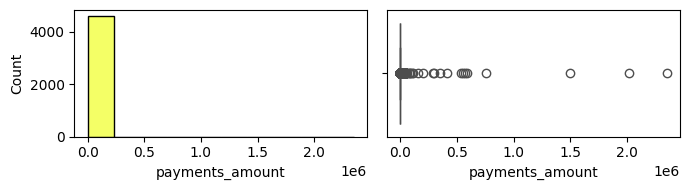

ID: 827
Количество записей: 4365


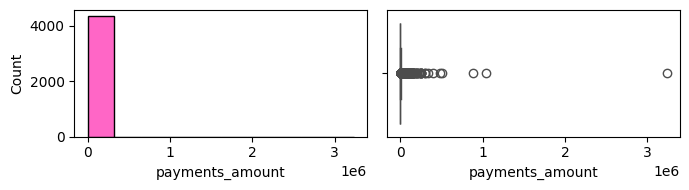

ID: 279
Количество записей: 3961


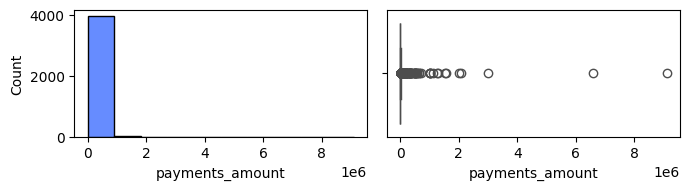

ID: 172
Количество записей: 3483


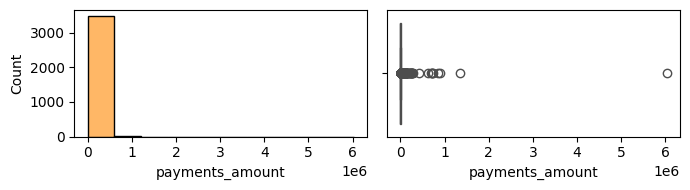

ID: 98
Количество записей: 3353


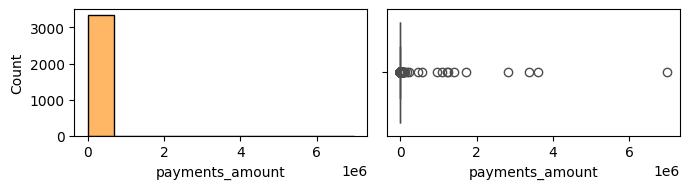

ID: 838
Количество записей: 3067


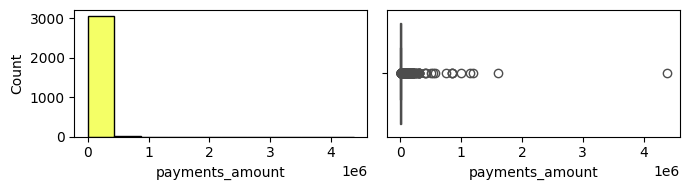

ID: 822
Количество записей: 3032


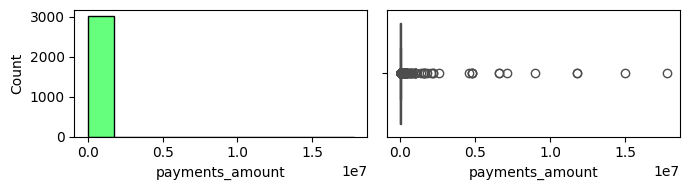

ID: 749
Количество записей: 2932


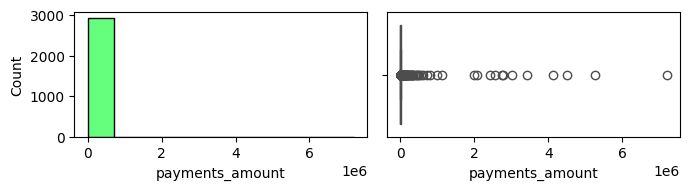

ID: 782
Количество записей: 1679


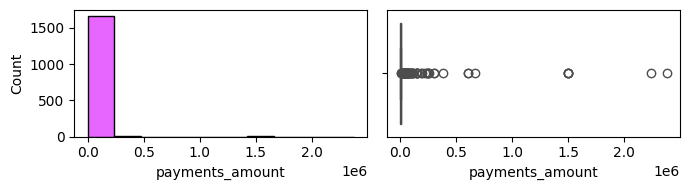

ID: 709
Количество записей: 1404


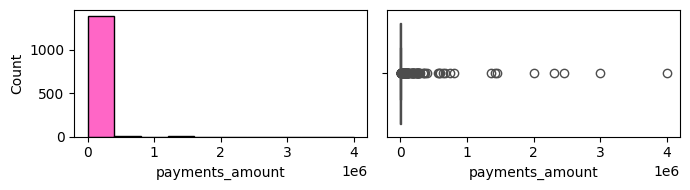

ID: 47
Количество записей: 1358


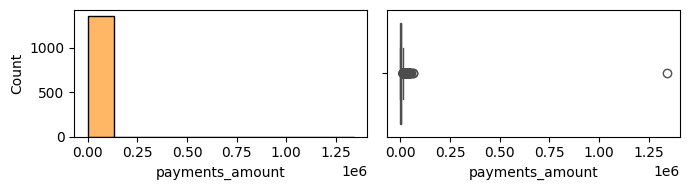

ID: 123
Количество записей: 1250


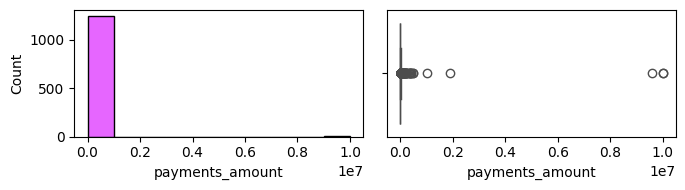

ID: 724
Количество записей: 1203


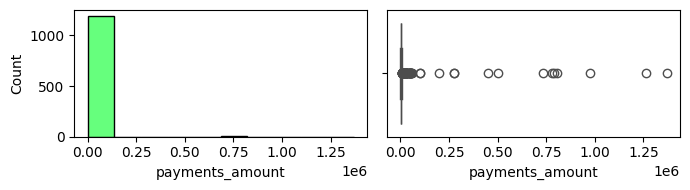

ID: 792
Количество записей: 1097


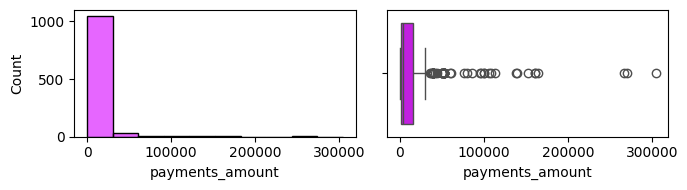

ID: 777
Количество записей: 687


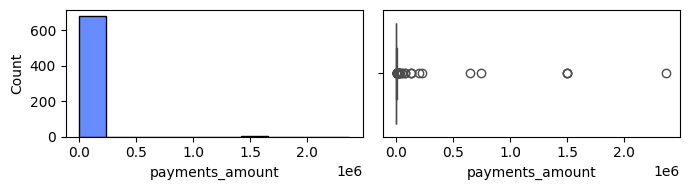

ID: 197
Количество записей: 622


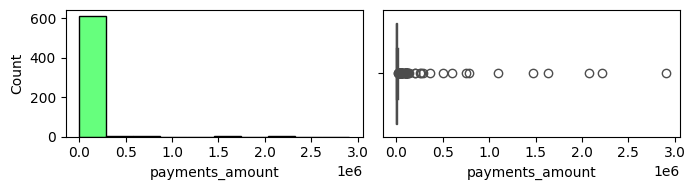

ID: 816
Количество записей: 619


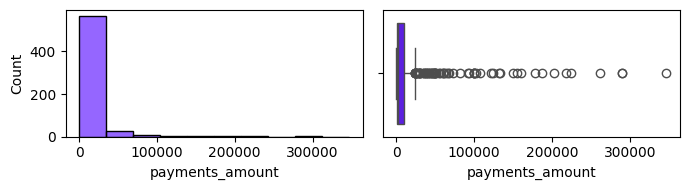

ID: 714
Количество записей: 490


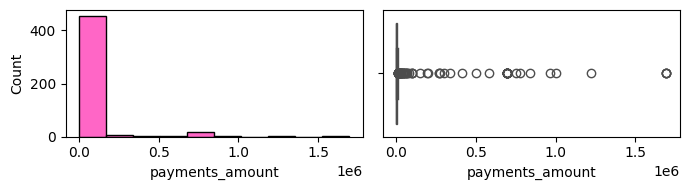

ID: 877
Количество записей: 412


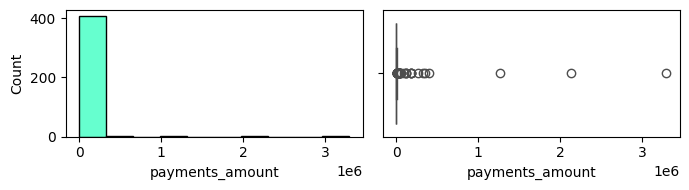

ID: 168
Количество записей: 410


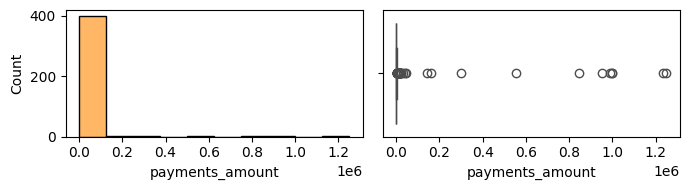

ID: 712
Количество записей: 386


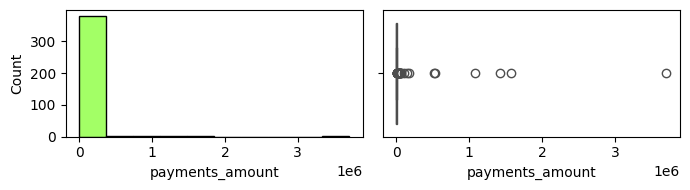

ID: 256
Количество записей: 368


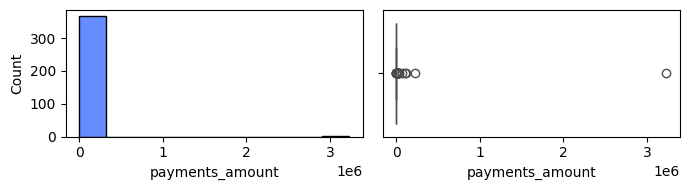

ID: 272
Количество записей: 357


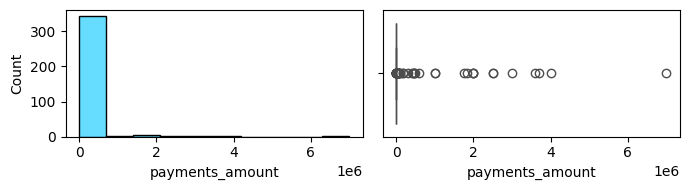

ID: 876
Количество записей: 311


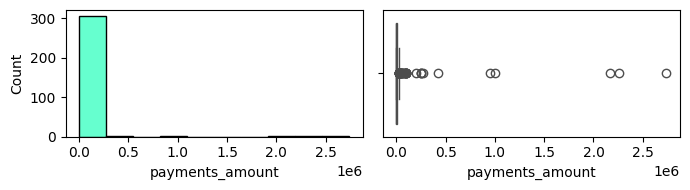

ID: 65
Количество записей: 292


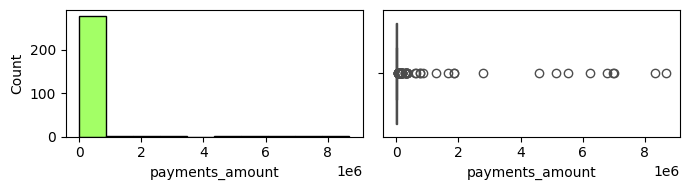

ID: 795
Количество записей: 185


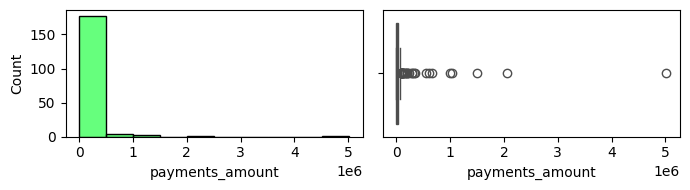

ID: 732
Количество записей: 112


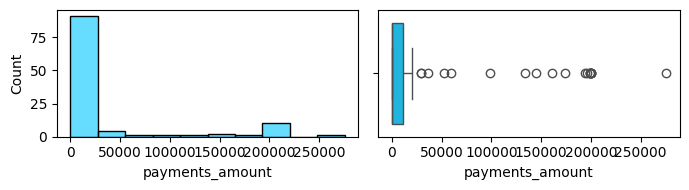

ID: 176
Количество записей: 107


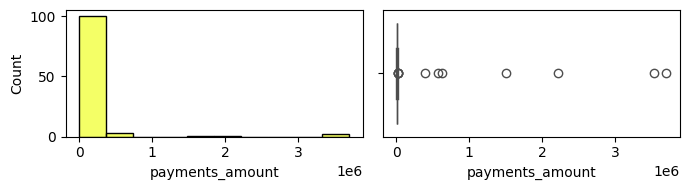

ID: 886
Количество записей: 39


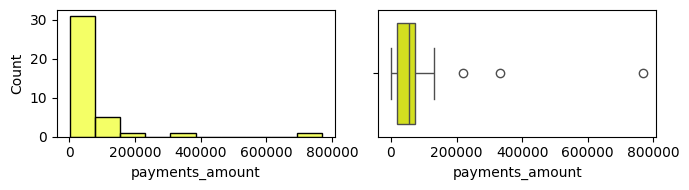

ID: 284
Количество записей: 9


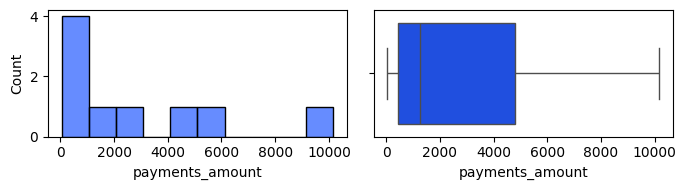

ID: 874
Количество записей: 4


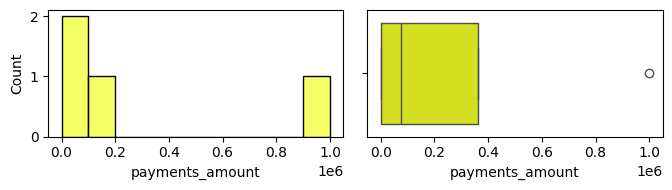

ID: 157
Количество записей: 2


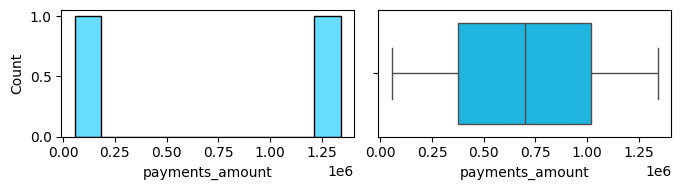

In [25]:
ids = data['user_id'].value_counts()

for id,count in ids.items():
    print('ID:',id)
    print('Количество записей:', count)
    fig = hist_box(data[data['user_id'] == id], 'payments_amount')
    plt.show()
    plt.close(fig)

Судя по графикам распределения платежей, выбросы есть, но обусловлены редкими поступлениями - далее при обучении моделей можно будет отбросить выбросы (значения превышающие 95% перцениль по аналогии с тестовыми данными) или оставить для более широкого обучения - надо будем смотреть по метрикам.

/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable contractor_id is large: 53610. Are you sure this is not an interval variable? Analysis for pairs of variables including contractor_id can be slow.
  warnings.warn(
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/phik/bivariate.py:241: UserWarning: Many cells: 7237350. Are interval variables set correctly?
  warnings.warn(
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/phik/bivariate.py:241: UserWarning: Many cells: 7183740. Are interval variables set correctly?
  warnings.warn(
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/phik/bivariate.py:241: UserWarning: Many cells: 7987890. Are interval variables set correctly?
  warnings.warn(
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/phik/bivariate.py:241: UserWarning: Many cells: 3216600. Are interval variables set correctly?
  warnings.warn(
/opt/anaconda3/

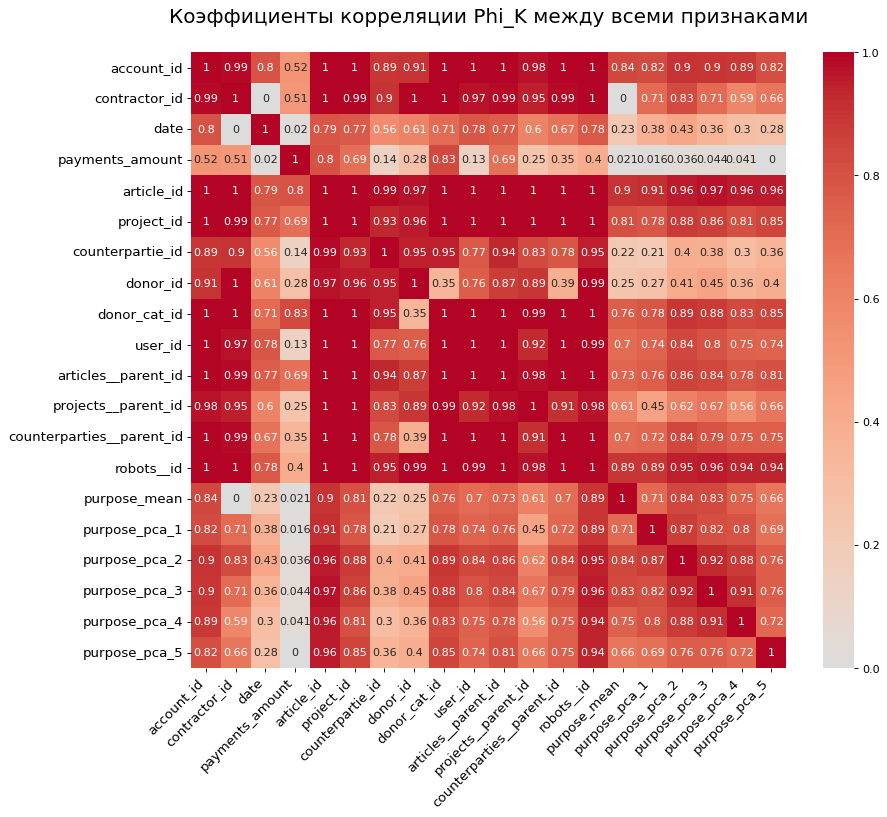

In [26]:
# проверим есть ли уже файл с матрицей или запустим расчет
if not os.path.exists("phik_correlation_matrix_full.parquet"):
    data_corr = data.drop('id', axis=1)
    data_corr['date'] = (pd.to_datetime(data_corr['date'], errors='coerce')).astype('int64') // 10**9

    phik_matrix = data_corr.phik_matrix(interval_cols=['payments_amount', 'purpose_mean', 'purpose_pca_1',
                                                       'purpose_pca_2', 'purpose_pca_3', 'purpose_pca_4',
                                                       'purpose_pca_5', 'date'])

    # запишем матрицу в файл
    phik_matrix.to_parquet("phik_correlation_matrix_full.parquet")
else:
    phik_matrix = pd.read_parquet("phik_correlation_matrix_full.parquet")

# сразу будем смотреть heatmap
plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(phik_matrix.values, xticklabels=phik_matrix.columns, yticklabels=phik_matrix.index, cmap='coolwarm', center=0, annot=True)

plt.title('Коэффициенты корреляции Phi_K между всеми признаками\n', fontsize=18)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation='horizontal')
plt.show()

Судя по данным корреляционной таблицы, многие id мультиколлинеарны и имеет смысл при обучении модели пробовать исключать как минимум вторичные идентификаторы, а также выбрать более подходящий вариант представления текстового поля с назначением платежа.  
Проведем агрегацию по дням и посмотрим на аналогичную таблицу корреляции.

<a id='Агрегирование-данных-и-генерация-признаков'></a> 
## Агрегирование данных и генерация признаков
[К содержанию](#К-содержанию)

In [27]:
data = data.drop('id', axis=1)
data.head()

,account_id,contractor_id,date,payments_amount,article_id,project_id,counterpartie_id,donor_id,donor_cat_id,user_id,articles__parent_id,projects__parent_id,counterparties__parent_id,robots__id,purpose_mean,purpose_pca_1,purpose_pca_2,purpose_pca_3,purpose_pca_4,purpose_pca_5
0,2051,83878,2020-11-20,1000.00000000,0,0,0,0,0,838,0,0,0,0,0.00094185,-5.38070059,-1.04426587,-0.23564315,-0.04214036,0.05035734
1,2052,40261,2020-12-06,800.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671
2,2052,40261,2020-12-06,100.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671
3,2052,40261,2020-12-06,300.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671
4,2052,40261,2020-12-06,300.00000000,0,0,0,0,0,838,0,0,0,0,-0.00270794,2.40096283,-2.15824342,-2.43168974,0.44952154,0.45905873


Сначала кодирование категориальных столбцов с различными id попробуем сделать с помощью target_encoding:

- задаем список колонок для кодирования (id_cols) и параметр сглаживания (smoothing_factor)
- агрегируем цель: создаем daily_target_agg - таблицу, где для каждой пары (user_id, date_day) есть суммарный payments_amount (daily_target_sum).
- присоединяем дневную сумму обратно в основной df. Теперь у каждой строки есть общую сумму платежей за свой день и своего пользователя.
- считаем среднее значение дневных сумм (user_mean_daily_sum) для каждого user_id. Это значение будет использоваться для "подтягивания" средних по редким категориям при сглаживании.
- далее прогоняем Target Encoding в цикле:

  - Проходим по каждой категориальной колонке col из id_cols.
  - Группируем data (который уже содержит daily_target_sum) по user_id и col.
  - Для каждой группы (user_id, category_value) считаем:  
        group_mean_daily_sum: Среднее значение колонки daily_target_sum для этой группы. Это и есть искомое среднее дневных сумм для этой категории у этого пользователя.  
        group_count: Количество строк (транзакций), попавших в эту группу.  
  - применяем формулу для сглаживания.  
  - присоединяем результат (encoded_col_name) обратно к data по ключам user_id и col.
- Удаляем временные столбцы date_day и daily_target_sum.

In [28]:
smoothing_factor = 10 # зададим параметр сглаживания, который пригодится при кодировании, если значений ктегории будет мало

id_cols = [
    'account_id', 'contractor_id', 'article_id', 'project_id',
    'counterpartie_id', 'donor_id', 'donor_cat_id',
    'articles__parent_id', 'projects__parent_id',
    'counterparties__parent_id', 'robots__id'
]

# агрегация целевого признака payments_amount по дням и пользователям
daily_target_agg = data.groupby(['user_id', 'date'])['payments_amount'].sum().reset_index()
daily_target_agg.rename(columns={'payments_amount': 'daily_target_sum'}, inplace=True)

# расчет средней дневной суммы для каждого пользователя + добавляем к каждому платежу
user_mean_daily_sum = daily_target_agg.groupby('user_id')['daily_target_sum'].mean().to_dict()
data_te = pd.merge(data, daily_target_agg, on=['user_id', 'date'], how='left')

# кодируем каждый из столбцов id_cols с помощью Target Encoding со сглаживанием (используя среднее значение платежей этого пользователя)
for col in id_cols:
    print(f"Считаем колонку: {col}")
    encoded_col_name = f'{col}_target_encoded_user_mean'

    # считаем среднее daily_target_sum и количество строк для каждой комбинации user_id и категории в col
    stats = data_te.groupby(['user_id', col])['daily_target_sum'].agg(['mean', 'size'])
    stats.rename(columns={'mean': 'group_mean_daily_sum', 'size': 'group_count'}, inplace=True)

    # берем user_id из индекса stats
    current_user_ids = stats.index.get_level_values('user_id')
    # сопоставляем каждому user_id его среднее значение, используя рассчитанный словарь
    user_specific_means_for_smoothing = current_user_ids.map(user_mean_daily_sum)
    
    # применяем сглаживане со средним по user_id
    stats[encoded_col_name] = (stats['group_mean_daily_sum'] * stats['group_count'] +
                               user_specific_means_for_smoothing * smoothing_factor) / \
                              (stats['group_count'] + smoothing_factor)

    # убираем технические столбцы
    stats_to_merge = stats[[encoded_col_name]].reset_index()

    # присоединяем рассчитанные кодированные значения обратно к основному датафрейму
    data_te = pd.merge(data_te, stats_to_merge, on=['user_id', col], how='left')

#  и убираем промежуточный столбец с дневными суммами таргета, который использовали при кодировании
data_te.drop(columns=['daily_target_sum'], inplace=True, errors='ignore')

data_te.head()

Считаем колонку: account_id
Считаем колонку: contractor_id
Считаем колонку: article_id
Считаем колонку: project_id
Считаем колонку: counterpartie_id
Считаем колонку: donor_id
Считаем колонку: donor_cat_id
Считаем колонку: articles__parent_id
Считаем колонку: projects__parent_id
Считаем колонку: counterparties__parent_id
Считаем колонку: robots__id


,account_id,contractor_id,date,payments_amount,article_id,project_id,counterpartie_id,donor_id,donor_cat_id,user_id,articles__parent_id,projects__parent_id,counterparties__parent_id,robots__id,purpose_mean,purpose_pca_1,purpose_pca_2,purpose_pca_3,purpose_pca_4,purpose_pca_5,account_id_target_encoded_user_mean,contractor_id_target_encoded_user_mean,article_id_target_encoded_user_mean,project_id_target_encoded_user_mean,counterpartie_id_target_encoded_user_mean,donor_id_target_encoded_user_mean,donor_cat_id_target_encoded_user_mean,articles__parent_id_target_encoded_user_mean,projects__parent_id_target_encoded_user_mean,counterparties__parent_id_target_encoded_user_mean,robots__id_target_encoded_user_mean
0,2051,83878,2020-11-20,1000.00000000,0,0,0,0,0,838,0,0,0,0,0.00094185,-5.38070059,-1.04426587,-0.23564315,-0.04214036,0.05035734,94351.42857074,38833.01789474,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415
1,2052,40261,2020-12-06,800.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671,35767.75511686,64025.40501188,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415
2,2052,40261,2020-12-06,100.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671,35767.75511686,64025.40501188,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415
3,2052,40261,2020-12-06,300.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671,35767.75511686,64025.40501188,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415
4,2052,40261,2020-12-06,300.00000000,0,0,0,0,0,838,0,0,0,0,-0.00270794,2.40096283,-2.15824342,-2.43168974,0.44952154,0.45905873,35767.75511686,64025.40501188,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415,83938.47304415


**Кодирование с примененем target_encoding требует дополнительных преобразований, чтобы избежать утечки таргета при подсчетах средних и сглаживаний, при этом на тестовом датасете важность категориальных признаков была незначительна - усложнение расчетов по этим признакам выглядит нецелесообразным, предлагается заменить на частотное кодирование, которое проще в реализации, не дает утечки таргета, но менее информативно.**

In [29]:
# закодируем данные с поомщью frequency_encoding по каждому user_id
id_cols = [
    'account_id', 'contractor_id', 'article_id', 'project_id',
    'counterpartie_id', 'donor_id', 'donor_cat_id',
    'articles__parent_id', 'projects__parent_id',
    'counterparties__parent_id', 'robots__id'
]

data_fe = data.copy()

# создаем временный столбец с общим количеством записей для каждого пользователя
data_fe['user_total_counts_col'] = data_fe.groupby('user_id')['user_id'].transform('size')

# кодируем каждый из столбцов id_cols
for col in id_cols:
    
    encoded_col_name = f'{col}_ufreq' #задаем имя столбцу
    # считаем количество вхождений категории 'col' для данного 'user_id'
    numerator = data_fe.groupby(['user_id', col])[col].transform('size')
    # считаем долю и записываем в столбец
    data_fe[encoded_col_name] = numerator.astype(float) / data_fe['user_total_counts_col'].astype(float)

# удаляем временный столбец с общим количеством
data_fe.drop(columns=['user_total_counts_col'], inplace=True)

display(data_fe.head(10))

,account_id,contractor_id,date,payments_amount,article_id,project_id,counterpartie_id,donor_id,donor_cat_id,user_id,articles__parent_id,projects__parent_id,counterparties__parent_id,robots__id,purpose_mean,purpose_pca_1,purpose_pca_2,purpose_pca_3,purpose_pca_4,purpose_pca_5,account_id_ufreq,contractor_id_ufreq,article_id_ufreq,project_id_ufreq,counterpartie_id_ufreq,donor_id_ufreq,donor_cat_id_ufreq,articles__parent_id_ufreq,projects__parent_id_ufreq,counterparties__parent_id_ufreq,robots__id_ufreq
0,2051,83878,2020-11-20,1000.00000000,0,0,0,0,0,838,0,0,0,0,0.00094185,-5.38070059,-1.04426587,-0.23564315,-0.04214036,0.05035734,0.81643300,0.00032605,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
1,2052,40261,2020-12-06,800.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
2,2052,40261,2020-12-06,100.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
3,2052,40261,2020-12-06,300.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
4,2052,40261,2020-12-06,300.00000000,0,0,0,0,0,838,0,0,0,0,-0.00270794,2.40096283,-2.15824342,-2.43168974,0.44952154,0.45905873,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
5,2052,40261,2020-12-06,450.00000000,0,0,0,0,0,838,0,0,0,0,-0.00270794,2.40096283,-2.15824342,-2.43168974,0.44952154,0.45905873,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
6,2052,40261,2020-12-06,150.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
7,2052,40261,2020-12-06,500.00000000,0,0,0,0,0,838,0,0,0,0,-0.00174428,1.72844315,-1.75944328,-1.24354970,0.47807479,0.48644671,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
8,2052,40261,2020-12-06,100.00000000,0,0,0,0,0,838,0,0,0,0,-0.00270794,2.40096283,-2.15824342,-2.43168974,0.44952154,0.45905873,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000
9,2052,40261,2020-12-06,1000.00000000,0,0,0,0,0,838,0,0,0,0,-0.00270794,2.40096283,-2.15824342,-2.43168974,0.44952154,0.45905873,0.18324095,0.18454516,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000


In [30]:
# сделаем проверку по разным user_id и закодированным столбцам - сумма долей должна быть ~1.0
for i in range(5):
    user_id_to_check = np.random.choice(data_fe['user_id'].unique())
    id_col_to_check = np.random.choice(id_cols)
    print(f"\nПроверка суммы долей для user_id={user_id_to_check} по колонке {id_col_to_check}:")
    print(data_fe[data_fe['user_id'] == user_id_to_check].groupby(id_col_to_check)[f'{id_col_to_check}_ufreq'].first().sum())


Проверка суммы долей для user_id=284 по колонке project_id:
1.0

Проверка суммы долей для user_id=888 по колонке robots__id:
1.0

Проверка суммы долей для user_id=172 по колонке counterpartie_id:
1.0

Проверка суммы долей для user_id=284 по колонке counterparties__parent_id:
1.0

Проверка суммы долей для user_id=812 по колонке donor_cat_id:
1.0


Теперь агрегируем полученные данные до уровня дня (недели/месяца), используя следующую стратегию:

**Идентификаторы дня/пользователя**: user_id, date (нужно будет извлечь день) — они станут индексами или ключами группировки.

**Целевая переменная (payments_amount)**:

    sum(): Обязательно — общая сумма платежей за день для пользователя. Это, вероятно, ваш основной таргет на дневном уровне, если вы предсказываете дневные траты.
    count(): Количество транзакций за день.
    mean(), median(), std(), min(), max(): Статистики по размерам отдельных платежей за день.

**Кодированные текстовые признаки (purpose_*)**:

    mean(): Вероятно, лучший вариант. 
    
**Таргет-кодированные (*_target_encoded_user_mean)**:

    mean(): логичный выбор, Показывает среднее "качество" (в терминах связи со средней дневной суммой) категорий, использованных в транзакциях этого дня.
    std(): может показать разнообразие использованных категорий с точки зрения их связи с дневной суммой.
    
**Исходные категориальные (id_cols)**: здесь важно - мы уже извлекли из них информацию через Target Encoding. Но сами исходные категории тоже несут информацию на дневном уровне:

    nunique(): Самый важный агрегат здесь. Показывает, сколько уникальных счетов, контрагентов, статей и т.д. было задействовано за день. Это характеризует "разнообразие" или "сложность" активности дня.

К агрегированным данным далее добавим новые признаки с учетом временной составляющей(лаги, скользящие средние).

In [31]:
# агрегация платежей по дням и пользователям

# делаем список колонок для расчета nunique
nunique_cols = [
    'account_id', 'contractor_id', 'article_id', 'project_id',
    'counterpartie_id', 'donor_id', 'donor_cat_id',
    'articles__parent_id', 'projects__parent_id',
    'counterparties__parent_id', 'robots__id'
]

# делаем список колонок с кодированными значениями текстового поля
purpose_mean_cols = [
    'purpose_mean', 'purpose_pca_1', 'purpose_pca_2',
    'purpose_pca_3', 'purpose_pca_4', 'purpose_pca_5'
]

# делаем список кодированных категориальных колонок
col_ufreq = [col for col in data_fe.columns if col.endswith('_ufreq')]

# агрегируем данные до уровня дня
data_daily_agg = data_fe.groupby(['user_id', 'date']).agg(
    **{f'day_{col}_nunique': (col, 'nunique') for col in nunique_cols},
    
    day_payments_sum=('payments_amount', 'sum'),
    day_payments_count=('payments_amount', 'count'),
    day_min_payment=('payments_amount', 'min'),
    day_max_payment=('payments_amount', 'max'),
    
    **{f'day_{col}': (col, 'mean') for col in purpose_mean_cols},
    
    **{f'{col}_mean': (col, 'mean') for col in col_ufreq},
    **{f'{col}_std': (col, 'std') for col in col_ufreq},
                                                          
    ).reset_index()

# заполним NaN в std колонках нулями (там где было одно наблюдение/платеж)
std_cols = [col for col in data_daily_agg.columns if col.endswith('_std')]
data_daily_agg[std_cols] = data_daily_agg[std_cols].fillna(0)

data_daily_agg.head()

,user_id,date,day_account_id_nunique,day_contractor_id_nunique,day_article_id_nunique,day_project_id_nunique,day_counterpartie_id_nunique,day_donor_id_nunique,day_donor_cat_id_nunique,day_articles__parent_id_nunique,day_projects__parent_id_nunique,day_counterparties__parent_id_nunique,day_robots__id_nunique,day_payments_sum,day_payments_count,day_min_payment,day_max_payment,day_purpose_mean,day_purpose_pca_1,day_purpose_pca_2,day_purpose_pca_3,day_purpose_pca_4,day_purpose_pca_5,account_id_ufreq_mean,contractor_id_ufreq_mean,article_id_ufreq_mean,project_id_ufreq_mean,counterpartie_id_ufreq_mean,donor_id_ufreq_mean,donor_cat_id_ufreq_mean,articles__parent_id_ufreq_mean,projects__parent_id_ufreq_mean,counterparties__parent_id_ufreq_mean,robots__id_ufreq_mean,account_id_ufreq_std,contractor_id_ufreq_std,article_id_ufreq_std,project_id_ufreq_std,counterpartie_id_ufreq_std,donor_id_ufreq_std,donor_cat_id_ufreq_std,articles__parent_id_ufreq_std,projects__parent_id_ufreq_std,counterparties__parent_id_ufreq_std,robots__id_ufreq_std
0,47,2021-12-31,2,1,1,1,1,1,1,1,1,1,1,14024.45000000,2,2606.47000000,11417.98000000,-0.00079836,-4.85856295,-3.46732879,-2.08071446,1.51740539,0.66024995,0.49594993,0.00147275,0.00147275,0.00147275,0.07879234,0.24153166,0.79455081,0.00147275,0.00147275,0.79455081,0.05301915,0.27440742,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
1,47,2022-01-02,1,1,1,1,1,1,1,1,1,1,1,100.00000000,1,100.00000000,100.00000000,0.00256474,-1.26372004,-1.76185882,-2.18307018,2.72084808,1.29721606,0.68998527,0.01693667,0.39322533,0.64580265,0.08615611,0.01693667,0.79455081,0.69955817,0.64580265,0.79455081,0.01325479,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2,47,2022-01-03,2,3,3,2,2,4,1,2,2,1,4,7166.50000000,4,10.00000000,6246.50000000,-0.00051924,2.76923323,-0.95646369,0.64849436,0.15622643,-0.30671227,0.59296760,0.26675258,0.33100147,0.55835788,0.41605302,0.13807069,0.79455081,0.59812224,0.57253314,0.79455081,0.12094993,0.19403535,0.30674405,0.07422812,0.17488954,0.09131075,0.15943257,0.00000000,0.20287187,0.14653903,0.00000000,0.13885003
3,47,2022-01-06,2,1,2,2,2,2,1,2,2,1,2,3616.10000000,3,6.10000000,3110.00000000,-0.00056044,2.82852817,-2.75504708,2.15866709,-0.55573797,-1.59044266,0.43127148,0.53240059,0.27638684,0.41261659,0.33996073,0.28325970,0.79455081,0.42906235,0.45041728,0.79455081,0.23981345,0.22405272,0.00000000,0.02635914,0.20194505,0.10543657,0.02848488,0.00000000,0.23425626,0.16920869,0.00000000,0.00467662
4,47,2022-01-10,2,3,3,2,3,3,1,2,2,1,5,34627.00000000,11,96.10000000,22000.00000000,0.00026056,2.40175939,-1.90487409,2.26705337,0.00706421,-0.09467556,0.47831035,0.29475164,0.28424153,0.45501406,0.26596599,0.25612532,0.79455081,0.47824341,0.48594189,0.79455081,0.13395368,0.20266331,0.27305573,0.04250624,0.18266617,0.21080863,0.08269669,0.00000000,0.21189276,0.15305502,0.00000000,0.10572510


In [32]:
# проверим на пропуски
data_daily_agg.isna().sum().sum()

0

In [33]:
# отсортируем по user_id и далее по датам
data_daily_agg.sort_values(['user_id', 'date'], inplace=True)

In [34]:
# заполним пропущенные дни нулевыми значениями, чтобы сохранить структуру временного ряда

# создадим функцию
def fill_missing_dates(group):
    full_range = pd.date_range(group['date'].min(), group['date'].max(), freq='D')
    group = group.set_index('date').reindex(full_range)
    group['user_id'] = group['user_id'].iloc[0]
    return group.reset_index().rename(columns={'index': 'date'})

# применим эту функцию к каждой группе после группировки по user_id
data_daily_agg_filled = data_daily_agg.groupby('user_id', group_keys=False).apply(fill_missing_dates)

# заполним пропущенные значения нулями
data_daily_agg_filled = data_daily_agg_filled.fillna(0)

/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_58755/2071054807.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_daily_agg_filled = data_daily_agg.groupby('user_id', group_keys=False).apply(fill_missing_dates)


In [35]:
# добавляем столбцы с днем недели и номером недели в месяце
data_daily_agg_filled['day_of_week'] = data_daily_agg_filled['date'].dt.weekday.astype('str')
#data['week_number'] = data_fund['datetime'].dt.isocalendar().week.astype('str')  # номер недели в году, пригодится для агрегации по неделям
data_daily_agg_filled['week_number'] = data_daily_agg_filled['date'].dt.day.sub(1).floordiv(7).add(1).astype('str') # номер недели в месяце


In [36]:
# добавим по платежам скользящее среднее  и лаги за последние n дней (например, 7 дней), исключая текущий день
ROLLING_WINDOW = 7
LAGS = 8

def rolling_mean(group, rolling_window, lags):
    group = group.sort_values('date')
    group['rolling_day_payments'] = (group['day_payments_sum'].shift(1)
                                                 .rolling(window=rolling_window, min_periods=1)
                                                 .mean())
    for lag in range(1, lags):
        group[f'day_payments_sum_lag_{lag}'] = group['day_payments_sum'].shift(lag)
    
    return group

# применим эту функцию к каждой группе после группировки по user_id
data_daily_agg_filled_added = (
    data_daily_agg_filled
    .groupby('user_id', group_keys=False)
    .apply(lambda group: rolling_mean(group, rolling_window=ROLLING_WINDOW, lags=LAGS)))


data_daily_agg_filled_added.head()


/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_58755/2492655260.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: rolling_mean(group, rolling_window=ROLLING_WINDOW, lags=LAGS)))


,date,user_id,day_account_id_nunique,day_contractor_id_nunique,day_article_id_nunique,day_project_id_nunique,day_counterpartie_id_nunique,day_donor_id_nunique,day_donor_cat_id_nunique,day_articles__parent_id_nunique,day_projects__parent_id_nunique,day_counterparties__parent_id_nunique,day_robots__id_nunique,day_payments_sum,day_payments_count,day_min_payment,day_max_payment,day_purpose_mean,day_purpose_pca_1,day_purpose_pca_2,day_purpose_pca_3,day_purpose_pca_4,day_purpose_pca_5,account_id_ufreq_mean,contractor_id_ufreq_mean,article_id_ufreq_mean,project_id_ufreq_mean,counterpartie_id_ufreq_mean,donor_id_ufreq_mean,donor_cat_id_ufreq_mean,articles__parent_id_ufreq_mean,projects__parent_id_ufreq_mean,counterparties__parent_id_ufreq_mean,robots__id_ufreq_mean,account_id_ufreq_std,contractor_id_ufreq_std,article_id_ufreq_std,project_id_ufreq_std,counterpartie_id_ufreq_std,donor_id_ufreq_std,donor_cat_id_ufreq_std,articles__parent_id_ufreq_std,projects__parent_id_ufreq_std,counterparties__parent_id_ufreq_std,robots__id_ufreq_std,day_of_week,week_number,rolling_day_payments,day_payments_sum_lag_1,day_payments_sum_lag_2,day_payments_sum_lag_3,day_payments_sum_lag_4,day_payments_sum_lag_5,day_payments_sum_lag_6,day_payments_sum_lag_7
0,2021-12-31,47.00000000,2.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,14024.45000000,2.00000000,2606.47000000,11417.98000000,-0.00079836,-4.85856295,-3.46732879,-2.08071446,1.51740539,0.66024995,0.49594993,0.00147275,0.00147275,0.00147275,0.07879234,0.24153166,0.79455081,0.00147275,0.00147275,0.79455081,0.05301915,0.27440742,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,47.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,5,1,14024.45000000,14024.45000000,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-02,47.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,100.00000000,1.00000000,100.00000000,100.00000000,0.00256474,-1.26372004,-1.76185882,-2.18307018,2.72084808,1.29721606,0.68998527,0.01693667,0.39322533,0.64580265,0.08615611,0.01693667,0.79455081,0.69955817,0.64580265,0.79455081,0.01325479,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,6,1,7012.22500000,0.00000000,14024.45000000,NaN,NaN,NaN,NaN,NaN
3,2022-01-03,47.00000000,2.00000000,3.00000000,3.00000000,2.00000000,2.00000000,4.00000000,1.00000000,2.00000000,2.00000000,1.00000000,4.00000000,7166.50000000,4.00000000,10.00000000,6246.50000000,-0.00051924,2.76923323,-0.95646369,0.64849436,0.15622643,-0.30671227,0.59296760,0.26675258,0.33100147,0.55835788,0.41605302,0.13807069,0.79455081,0.59812224,0.57253314,0.79455081,0.12094993,0.19403535,0.30674405,0.07422812,0.17488954,0.09131075,0.15943257,0.00000000,0.20287187,0.14653903,0.00000000,0.13885003,0,1,4708.15000000,100.00000000,0.00000000,14024.45000000,NaN,NaN,NaN,NaN
4,2022-01-04,47.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.0000000

In [37]:
# сдвигаем таргет на -1 для каждой группы по user_id
data_daily_agg_filled_added['day_payments_shifted'] = data_daily_agg_filled_added.groupby('user_id', group_keys=False)['day_payments_sum'].shift(-1)
#data_daily_agg_filled = data_daily_agg_filled.dropna(subset=['day_payments_shifted'])

In [38]:
# заполним пропущенные значения нулями (или удалим)
data_daily_agg_filled_added = data_daily_agg_filled_added.fillna(0)
#data_daily_agg_filled_added = data_daily_agg_filled_added.dropna()


<a id='Корреляция-данных-и-распределение-целевого-признака-после-агрегирования'></a> 
## Корреляция данных и распределение целевого признака после агрегирования
[К содержанию](#К-содержанию)

/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


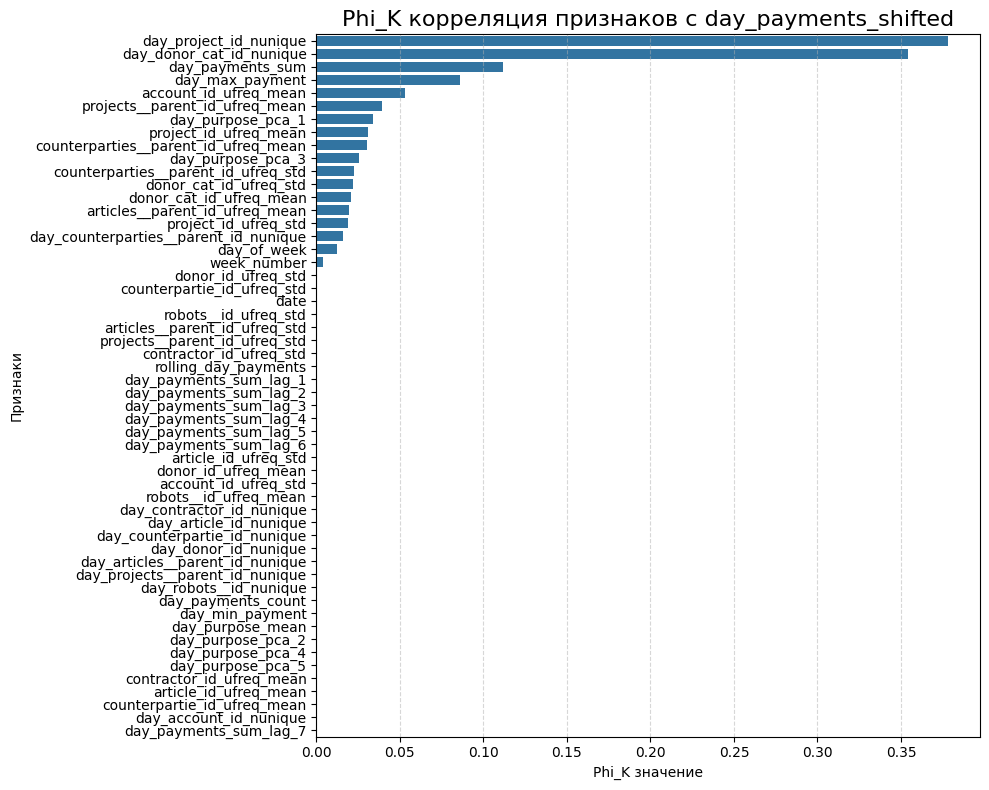

In [39]:
# посморим на корреляцию по Phi_K

data_corr = data_daily_agg_filled_added.copy()
data_corr['date'] = data_corr['date'].astype('int64') // 10**9
data_corr = data_corr.drop(['user_id',],axis=1)

# собираем список интервальных клонок
all_agg_cols = data_corr.columns.tolist()

interval_cols_agg = [col for col in all_agg_cols if col not in ['day_of_week', 'week_number']]

phik_matrix = data_corr.phik_matrix(interval_cols=interval_cols_agg)

# heatmap будет слишком  большим и неинформативным, посмотрим только barplot корреляции таргета с остальными признаками

phik_target_corr = phik_matrix.loc['day_payments_shifted'].drop('day_payments_shifted').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=phik_target_corr.values, y=phik_target_corr.index)
plt.title(f'Phi_K корреляция признаков с {"day_payments_shifted"}', fontsize=16)
plt.xlabel('Phi_K значение')
plt.ylabel('Признаки')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

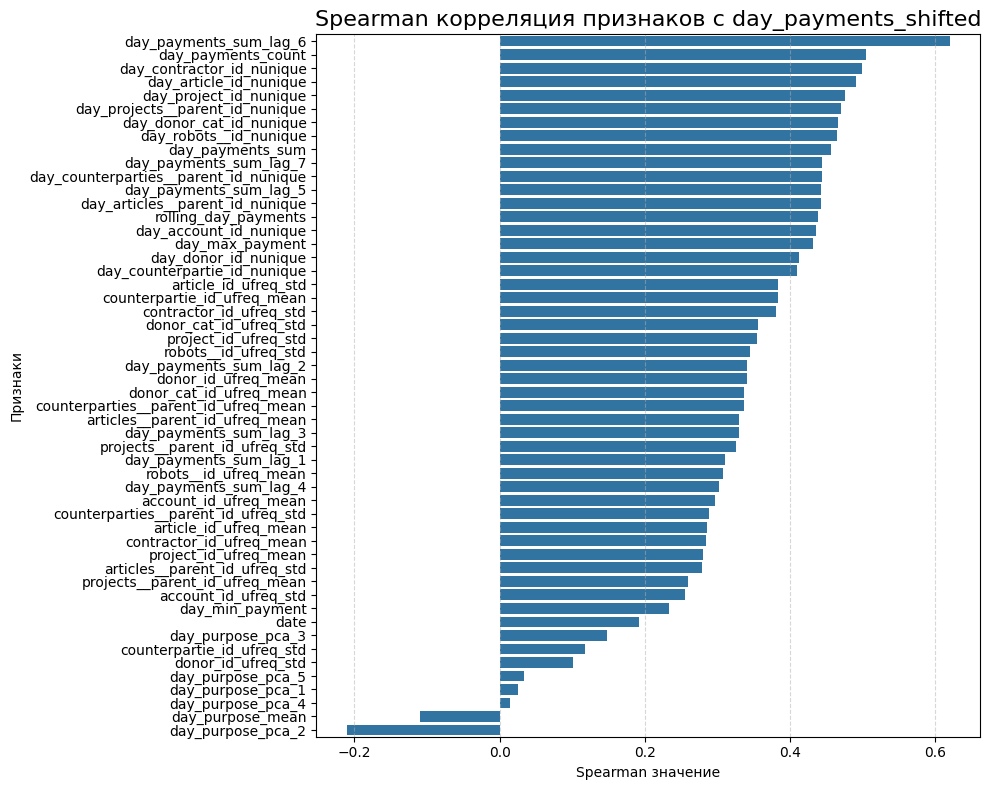

In [40]:
# и корреляцию Спирмена
spearman_target = data_daily_agg_filled_added.drop(['user_id','day_of_week', 'week_number'],axis=1)
spearman_target['date'] = spearman_target['date'].astype('int64') // 10**9
spearman_target_corr = spearman_target.corr(method='spearman')['day_payments_shifted'].drop('day_payments_shifted').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=spearman_target_corr.values, y=spearman_target_corr.index)
plt.title(f'Spearman корреляция признаков с {"day_payments_shifted"}', fontsize=16)
plt.xlabel('Spearman значение')
plt.ylabel('Признаки')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

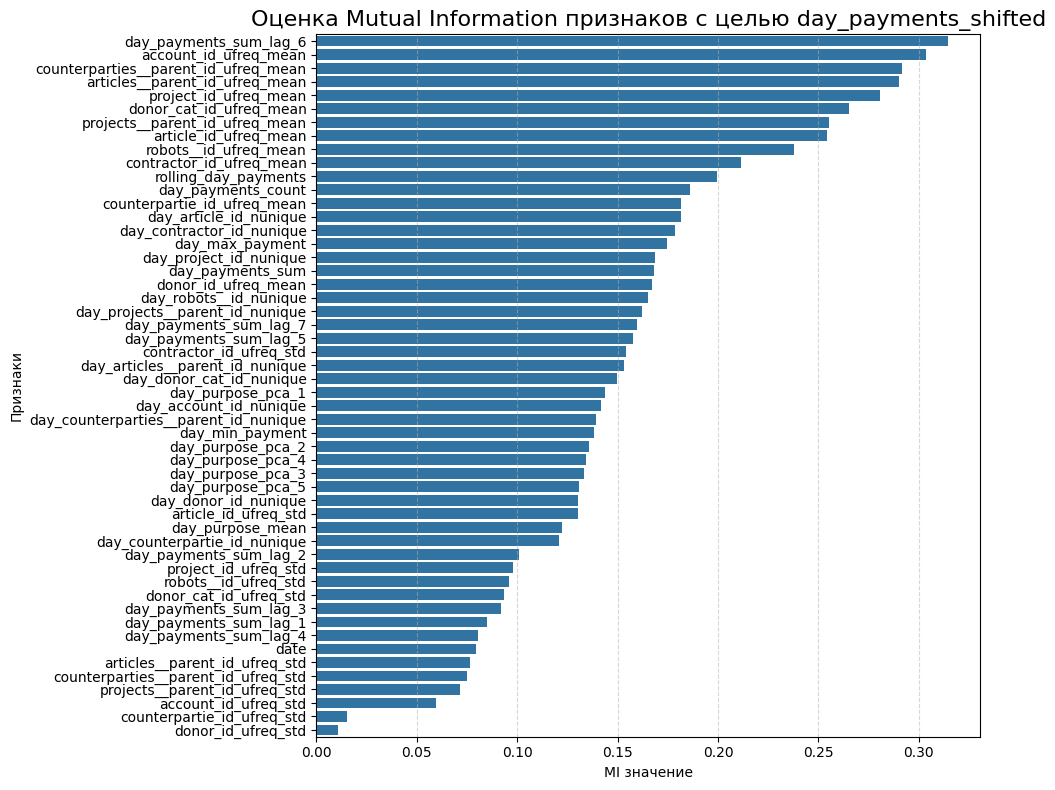

In [41]:
# и связь по Mutual Information
X = data_daily_agg_filled_added.drop(['user_id','day_of_week', 'week_number','day_payments_shifted'],axis=1)
X['date'] = X['date'].astype('int64') // 10**9
y = data_daily_agg_filled_added['day_payments_shifted']

# считаем Mutual Information и печатаем результаты
mi_scores = mutual_info_regression(X, y, discrete_features=False, random_state=RANDOM_STATE)

mi_series_sorted = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series_sorted.values, y=mi_series_sorted.index)
plt.title('Оценка Mutual Information признаков с целью day_payments_shifted', fontsize=16)
plt.xlabel('MI значение')
plt.ylabel('Признаки')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Корреляция по **Phi_K** вызывает вопросы:
Количество нулевых корреляций значительно. Он отбрасывает почти все признаки _nunique, _mean, _std, date, payments_count, purpose и т.д. Это КРАЙНЕ маловероятно, что все они не имеют никакой связи с завтрашними платежами.
Самые высокие корреляции по Phi_K - у day_project_id_nunique и day_donor_cat_id_nunique, но даже они довольно низкие (<0.4).
**Вывод по Phi_K**: Результаты выглядят ненадёжно и неполно. Вероятно, проблема в настройках (значимость, биннинг) или в том, как он обрабатывает распределения агрегированных данных.

**Spearman** выглядит гораздо информативнее:
- Показывает ненулевую корреляцию для всех признаков.
- Сильные Положительные Корреляции: day_payments_count, day_*_nunique (почти все ID), day_payments_sum, day_max_payment - 

В связи с разночтениями предыдущих двух методов для проверки использовали также анализ **Mutual Information**:

Лидеры - *_ufreq_mean: В отличие от Spearman, где лидировали _count и _nunique, MI ставит на первое место именно признаки средней доли частоты (_mean). Это говорит о том, что паттерн концентрации использования категорий сегодня (насколько часто в среднем используются те или иные статьи, проекты и т.д.) несет наибольшее количество информации (учитывая любые, не только монотонные, зависимости) о сумме платежей завтра.  
Важность _count, _nunique, _max_payment, _sum Подтверждена: Эти признаки идут сразу за _mean, показывая высокие значения MI. Это подтверждает их значимость, выявленную и Spearman'ом. Объем, разнообразие и пиковые значения активности сегодня сильно связаны с завтрашним результатом.  
Информативность _std Признаков: MI показывает, что признаки стандартного отклонения (_std) несут информацию, но их ранг ниже, чем у _mean и _count/_nunique. MI-оценки для них (~0.08-0.15, кроме нескольких совсем низких) не нулевые, но и не топовые. Это может означать, что их связь с таргетом, хотя и сильная по монотонности (Spearman), может быть менее сложной или всеобъемлющей, чем у _mean. Тем не менее, они однозначно информативны и несут сигнал, отличный от _mean.  
Purpose/PCA: Эти признаки показывают умеренную информативность (~0.13-0.14), что согласуется с выводами Spearman и указывает на их некоторую полезность.  
Дата (date): Имеет довольно низкую MI (0.075), но не нулевую. Временной фактор присутствует, но, возможно, слабее других сигналов.  
Низкая Информативность: Некоторые _std колонки (counterpartie_id_ufreq_std, donor_id_ufreq_std) показывают очень низкий MI, что делает их кандидатами на исключение.

Сравнение **MI** с **Spearman** и общие замечания:  
Оба метода (MI и Spearman) выделяют примерно одни и те же группы признаков как важные (_mean, _std, _count, _nunique, _sum, _max_payment).  
Расхождения в Рангах: Главное расхождение - в относительном ранжировании _mean (выше в MI) и _std (выше в Spearman). Это нормально, так как методы измеряют разные аспекты связи.  
Итоговый анализ признаков - после обчения моделей и анализ фактической важности(feature importance). Phi_K  в данном случае будем игнорировать.  

ID: 838.0
Количество записей: 1457


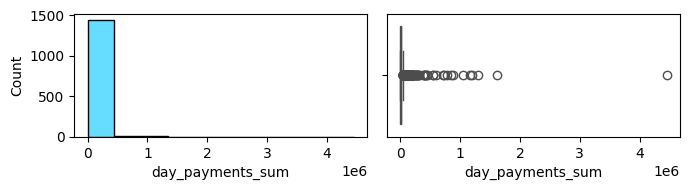

ID: 176.0
Количество записей: 1169


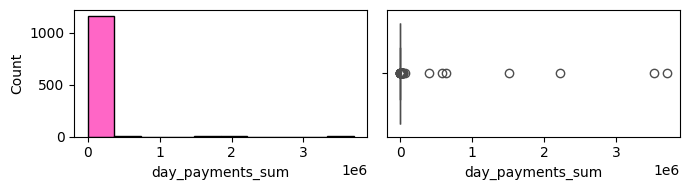

ID: 195.0
Количество записей: 759


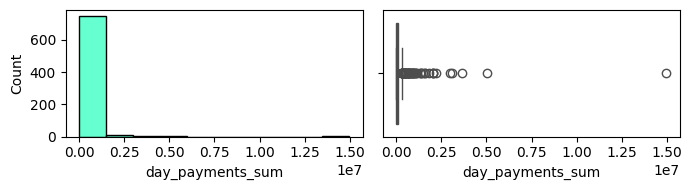

ID: 65.0
Количество записей: 759


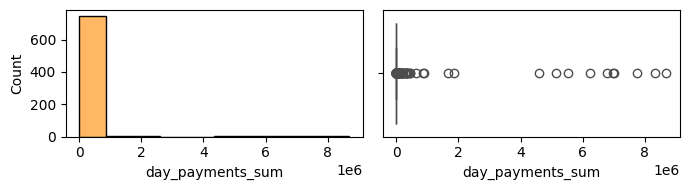

ID: 185.0
Количество записей: 758


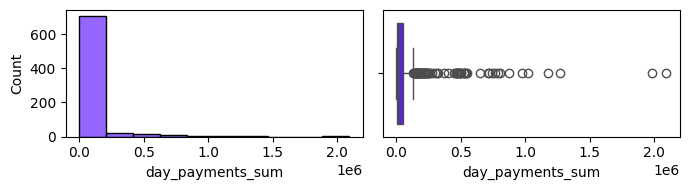

ID: 172.0
Количество записей: 758


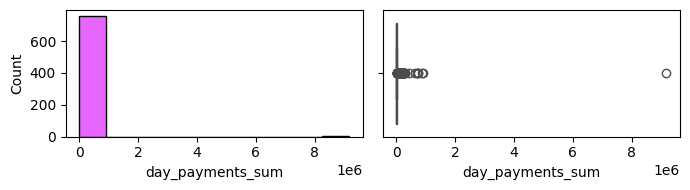

ID: 123.0
Количество записей: 729


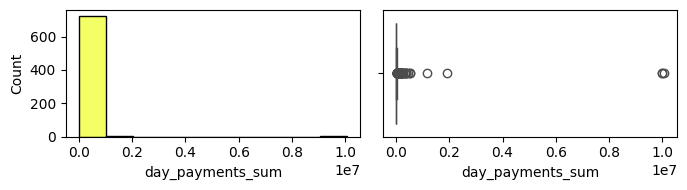

ID: 886.0
Количество записей: 673


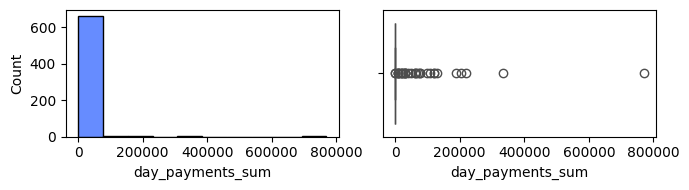

ID: 714.0
Количество записей: 665


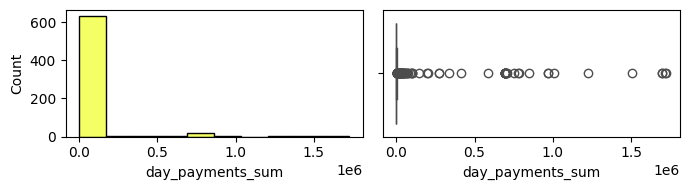

ID: 749.0
Количество записей: 609


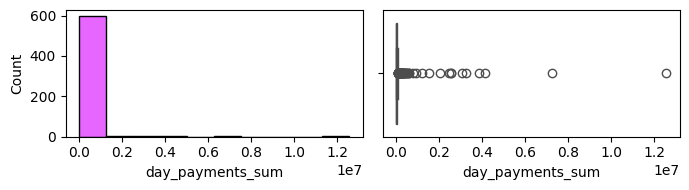

ID: 47.0
Количество записей: 486


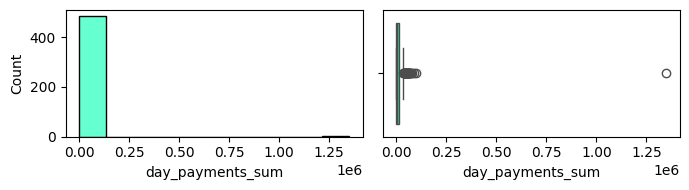

ID: 237.0
Количество записей: 482


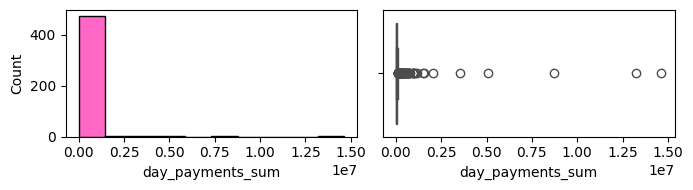

ID: 272.0
Количество записей: 443


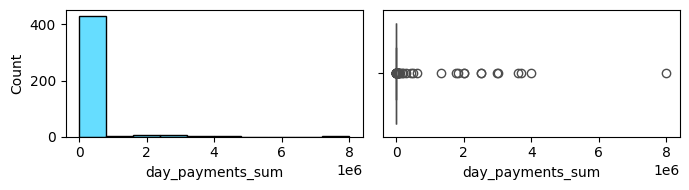

ID: 782.0
Количество записей: 405


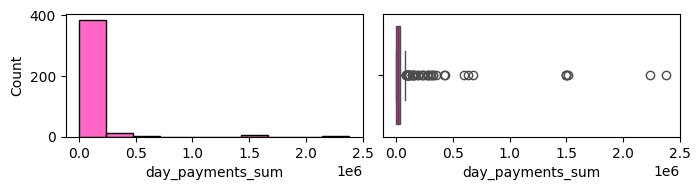

ID: 777.0
Количество записей: 405


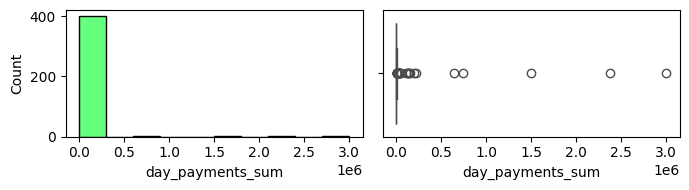

ID: 98.0
Количество записей: 397


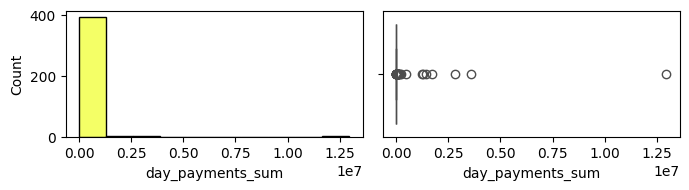

ID: 279.0
Количество записей: 395


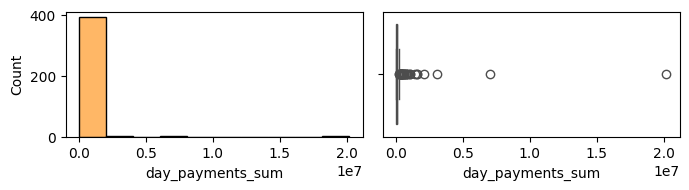

ID: 812.0
Количество записей: 394


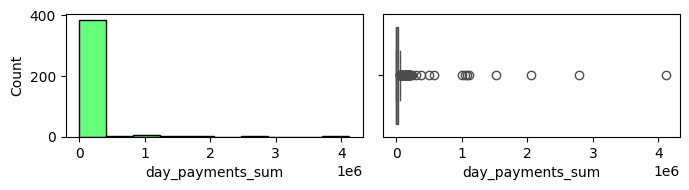

ID: 792.0
Количество записей: 394


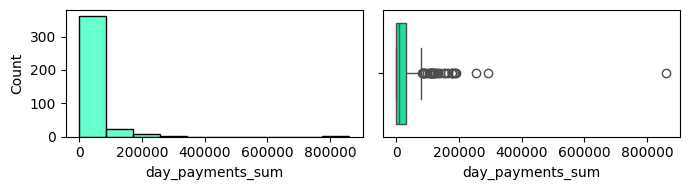

ID: 724.0
Количество записей: 394


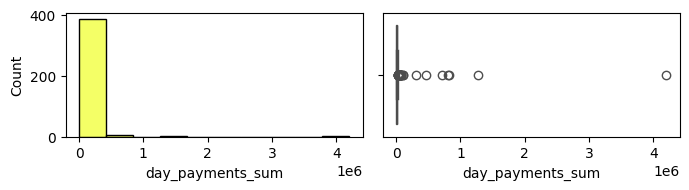

ID: 722.0
Количество записей: 394


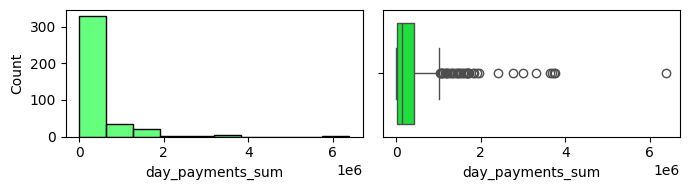

ID: 712.0
Количество записей: 394


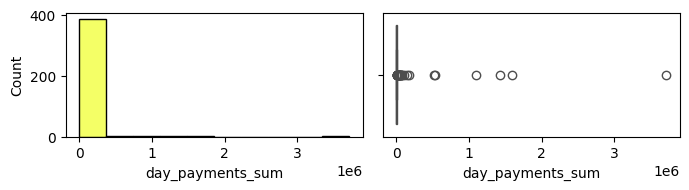

ID: 197.0
Количество записей: 394


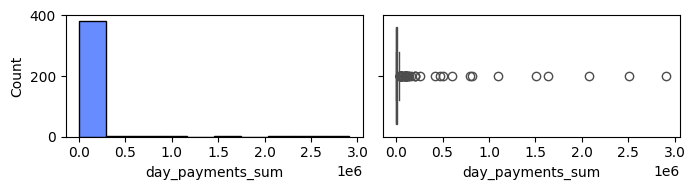

ID: 114.0
Количество записей: 394


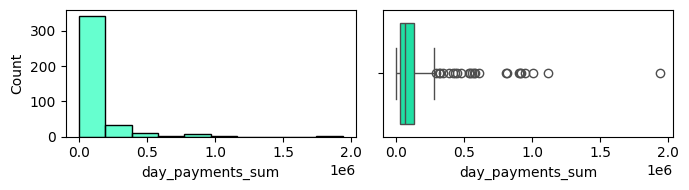

ID: 890.0
Количество записей: 393


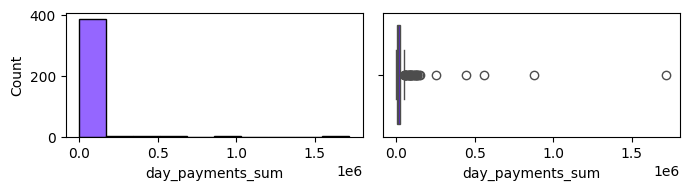

ID: 877.0
Количество записей: 392


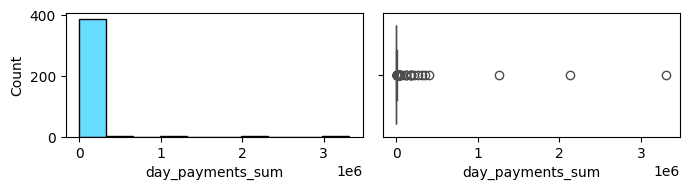

ID: 804.0
Количество записей: 391


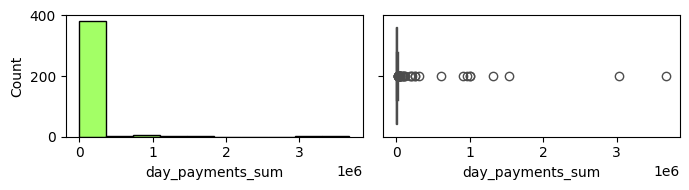

ID: 816.0
Количество записей: 373


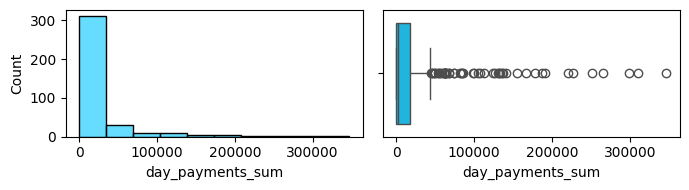

ID: 827.0
Количество записей: 366


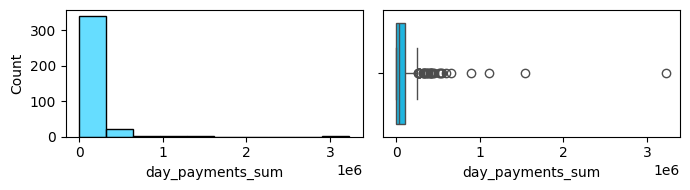

ID: 888.0
Количество записей: 336


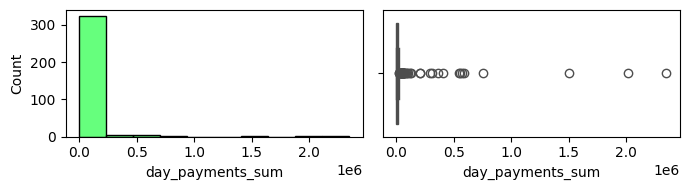

ID: 709.0
Количество записей: 331


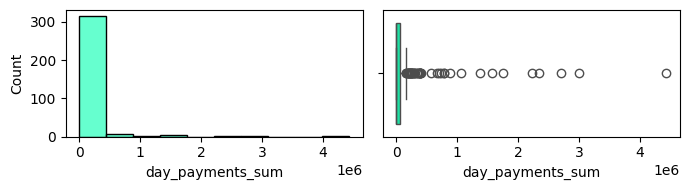

ID: 876.0
Количество записей: 329


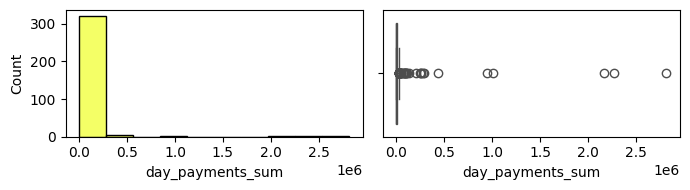

ID: 822.0
Количество записей: 316


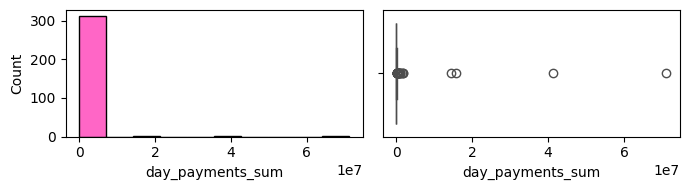

ID: 168.0
Количество записей: 304


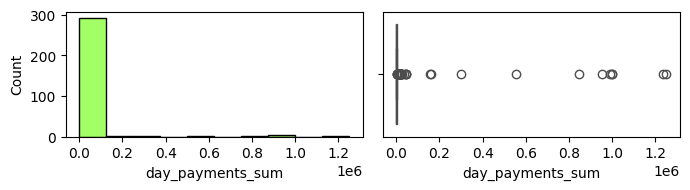

ID: 795.0
Количество записей: 160


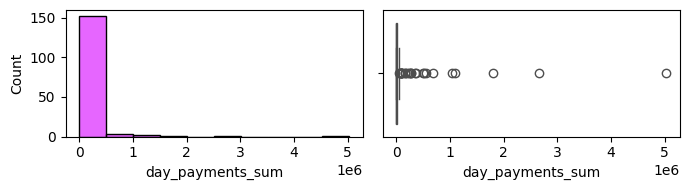

ID: 732.0
Количество записей: 58


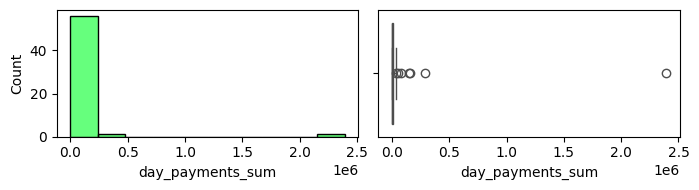

ID: 256.0
Количество записей: 21


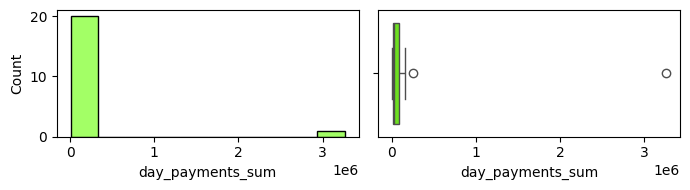

ID: 874.0
Количество записей: 11


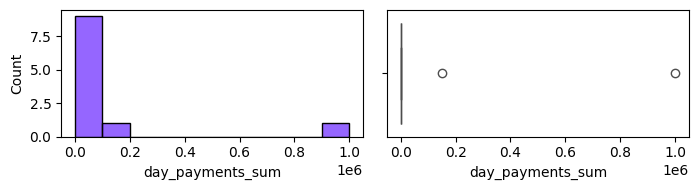

ID: 284.0
Количество записей: 1


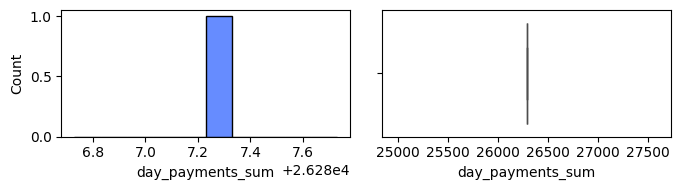

ID: 157.0
Количество записей: 1


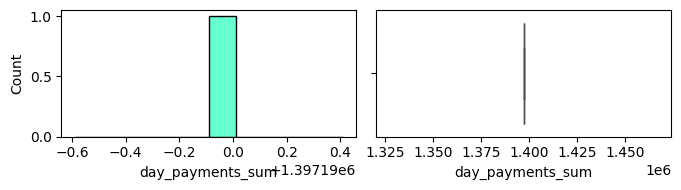

In [42]:
ids = data_daily_agg_filled_added['user_id'].value_counts()

for id,count in ids.items():
    print('ID:',id)
    print('Количество записей:', count)
    fig = hist_box(data_daily_agg_filled_added[data_daily_agg_filled_added['user_id'] == id], 'day_payments_sum')
    plt.show()
    plt.close(fig)

Судя по графикам агрегированных данных по платежам - есть чувствительные единичные выбросы, которые, возможно, имеет смысл заменить на медианные значения для каждого фонда, с порогом 95-перцентиля (аналогично делали на тестовом датасете) и сравнить результативность метрик при обучении моделей с заменой выбросов и без.